# BT5153 Group Prject Codes

# Topic: Toxic Comment Detection

In [ ]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [ ]:
# link to Google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import packages
import os
import re
import json
import random
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from collections import Counter
from datasets import Dataset
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from dataclasses import dataclass
from typing import Dict, List, Optional, Union
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

In [ ]:
# import datasets
# Update these paths if your files are stored elsewhere.

TOXIC_TRAIN_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/jigsaw-toxic-comment-train.csv"
UNINTENDED_BIAS_TRAIN_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/jigsaw-unintended-bias-train.csv"
VALIDATION_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/validation.csv"
TEST_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/test.csv"

# Optional: if you also have test labels later
TEST_LABELS_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/test_labels.csv"

# Recommended Pipeline
---
## Module 0: Problem Framing
### Task: For each input comment, the model should output:
- a toxicity probability between 0 and 1.
- based on the threshold, a predicted toxicity label.

### Core project setting:
- **Train**: English-only data
- **Val/Test**: multilingal data
- **Goal**: evaluate **zero-shot cross-lingual generalization**

### Research questions the final report should answer:
1. Can a model trained only on English generalize to other languages?
2. How large is the performance gap across different model families?
3. What threshold design is most suitable for a moderation setting?
4. Which languages are the hardest, and why?
5. Are more complex models actually worth the extra cost?
6. Why to incorporate each model? Why baseline? Why each selected model is **supposed** to be stronger?
7. Compare multiple threshold design (e.g., no tuning / default 0.5, global recall-constrained threshold, language-specific recall-constrained threshold) and compare performance, recall, false-positive burdens, etc.
8. **If feasible**: per-language robustness analysis
---

## Module 1: Data Loading and sanity check

### What to load:
**Training inputs**:
- "jigsaw-toxic-comment-train.csv"
- "jigsaw-unintended-bias-train.csv"
- "jigsaw-toxic-comment-train-processed-seqlen128.csv" **NO NEED cuz only for BERT!!!**
- "jigsaw-unintended-bias-train-processed-seqlen128.csv"  **NO NEED cuz only for BERT!!!**

**Validation inputs**:
- "validation.csv"
- "validation-processed-seqlen128.csv" **NO NEED cuz only for BERT!!!**

**Test inputs**:
- "test.csv"
- "test-processed-seqlen128.csv" **NO NEED cuz only for BERT!!!**
- "test-labels.csv"

### What to check:
For each file, check:
1. shape
2. column names
3. data types
4. missing values
5. toxic class proportion
6. language distribution
7. whether the training data is truly English-only
8. which languages appear in validation and test
---

## Module 2. Data Preparation

### 2.1 Training Set Construction

### 2.2 Text Cleaning
Recommended:
- Remove empty/null comments
- Strip whitespace
- Remove duplicates

Avoid:
- Stemming
- Heavy punctuation removal
- Stopword removal

### 2.3 Sampling Strategy
- Stage A: small subset for prototyping
- Stage B: full dataset for final training

---
## Module 3. Exploratory Data Analysis (EDA)

### Tasks
- Class imbalance analysis
- Comment length distribution
- Language distribution (validation)
- Toxic ratio per language
- Train vs validation/test domain gap

### Potential Insights
- Language imbalance affects stability
- Toxic comments may differ in length/style
- Cross-lingual gap reflects both language and domain shift
---
## Module 4. Modeling

### 4.1 Baseline 1: TF-IDF + Logistic Regression
- `TfidfVectorizer` (1–2 grams)
- `LogisticRegression` (optional class_weight="balanced")

**Purpose**
- Fast, interpretable benchmark
- Captures surface-level patterns

---

### 4.2 Baseline 2: Neural Models (Choose 1–2)
- BiLSTM (sequence modeling)
- CNN (local pattern extraction)

**Recommendation**
- Do not over-invest in all variants
- Focus on representative models

---

### 4.3 Core Model 1: mBERT
- Fine-tune on English data
- Evaluate zero-shot multilingual performance

---

### 4.4 Core Model 2: XLM-R
- Stronger multilingual transformer
- Likely best-performing model

**Key Analysis**
- Compare with mBERT
- Analyze performance differences across languages

---

## Module 5. Threshold Optimization

### 5.1 Define Recall Floor
- Example:
  - Recall ≥ 0.80 or 0.85

### 5.2 Threshold Strategies

#### Global Threshold
- One threshold for all languages
- Pros: simple, realistic, consistent

#### Language-Specific Threshold
- Separate threshold per language
- Pros: better performance
- Cons: complex, unstable, requires language info

### Goal
- Maximize F1 under recall constraint

---

## Module 6. Evaluation

### Metrics

#### Probability-level
- ROC-AUC (overall)
- ROC-AUC (per language)

#### Threshold-level
- Precision
- Recall
- F1

#### Optional
- PR-AUC
- FPR / FNR

---

### Required Breakdowns
- By model
- By language
- By threshold strategy

---

### Robustness / Fairness Analysis
- Best vs worst language performance
- Recall variance across languages
- Performance drop (English → non-English)

---

## Module 7. Error Analysis and Interpretation

### Tasks
- Analyze false positives / false negatives
- Identify hardest languages
- Detect common failure patterns

### Traditional Model Interpretation
- Top positive/negative tokens (Logistic Regression)

### Transformer Interpretation
- Case studies
- Compare predictions across models

---

## Final Project Storyline

1. Build baseline (TF-IDF + Logistic Regression)
2. Add neural baseline (BiLSTM / CNN)
3. Introduce transformers (mBERT, XLM-R)
4. Evaluate cross-lingual performance
5. Optimize threshold (recall-constrained)
6. Compare global vs language-specific thresholds
7. Conduct error analysis and deployment discussion

# Module 1: Data loading and processing

In [ ]:
# Basic Utility Functions
def check_file_exists(path: str) -> None:
    """Raise an error if the file does not exist."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")


def print_section(title: str) -> None:
    """Print a formatted section title."""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def standardize_text_column(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    """
    Standardize the text column name to 'comment_text'.

    Some datasets use 'content' instead of 'comment_text'.
    This function renames 'content' to 'comment_text' if needed.
    """
    df = df.copy()

    if "comment_text" in df.columns:
        return df

    if "content" in df.columns:
        df = df.rename(columns={"content": "comment_text"})
        return df

    raise ValueError(
        f"{dataset_name} does not contain 'comment_text' or 'content' column."
    )


def convert_toxic_to_binary(series: pd.Series, threshold: float = 0.5) -> pd.Series:
    """
    Convert a toxicity score to binary labels.

    Any value >= threshold is mapped to 1, otherwise 0.
    """
    return (series >= threshold).astype(int)


def summarize_dataframe(
    df: pd.DataFrame,
    dataset_name: str,
    text_col: str = "comment_text",
    label_col: str = "toxic",
    lang_col: str = "lang"
) -> dict:
    """
    Create a summary dictionary for a dataset.
    """
    summary = {
        "dataset": dataset_name,
        "n_rows": len(df),
        "n_columns": df.shape[1],
        "columns": list(df.columns),
        "missing_text": df[text_col].isna().sum() if text_col in df.columns else None,
        "empty_text": (
            (df[text_col].fillna("").astype(str).str.strip() == "").sum()
            if text_col in df.columns else None
        ),
        "duplicate_rows": df.duplicated().sum(),
        "duplicate_text": df[text_col].duplicated().sum() if text_col in df.columns else None,
        "has_lang": lang_col in df.columns,
        "has_label": label_col in df.columns,
        "toxic_positive_rate": (
            df[label_col].mean() if label_col in df.columns else None
        ),
        "num_languages": (
            df[lang_col].nunique() if lang_col in df.columns else None
        )
    }
    return summary


def preview_dataset(df: pd.DataFrame, dataset_name: str, n: int = 3) -> None:
    """
    Print a lightweight preview of the dataset.
    """
    print_section(f"{dataset_name} - Preview")
    print(df.head(n))
    print("\nData types:")
    print(df.dtypes)


def print_missing_value_report(df: pd.DataFrame, dataset_name: str) -> None:
    """
    Print missing value counts for all columns with at least one missing value.
    """
    print_section(f"{dataset_name} - Missing Value Report")
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)

    if len(missing) == 0:
        print("No missing values found.")
    else:
        print(missing)


def print_language_distribution(df: pd.DataFrame, dataset_name: str, top_n: int = 20) -> None:
    """
    Print language distribution if 'lang' exists.
    """
    if "lang" not in df.columns:
        print_section(f"{dataset_name} - Language Distribution")
        print("No 'lang' column found.")
        return

    print_section(f"{dataset_name} - Language Distribution")
    lang_counts = df["lang"].value_counts(dropna=False)
    lang_ratios = df["lang"].value_counts(normalize=True, dropna=False)

    lang_summary = pd.DataFrame({
        "count": lang_counts,
        "ratio": lang_ratios.round(4)
    })

    print(lang_summary.head(top_n))


def print_label_distribution(df: pd.DataFrame, dataset_name: str, label_col: str = "toxic") -> None:
    """
    Print label distribution if label column exists.
    """
    if label_col not in df.columns:
        print_section(f"{dataset_name} - Label Distribution")
        print(f"No '{label_col}' column found.")
        return

    print_section(f"{dataset_name} - Label Distribution")
    label_counts = df[label_col].value_counts(dropna=False).sort_index()
    label_ratios = df[label_col].value_counts(normalize=True, dropna=False).sort_index()

    label_summary = pd.DataFrame({
        "count": label_counts,
        "ratio": label_ratios.round(4)
    })

    print(label_summary)


def print_text_length_stats(df: pd.DataFrame, dataset_name: str, text_col: str = "comment_text") -> None:
    """
    Print basic text length statistics in characters and words.
    """
    if text_col not in df.columns:
        print_section(f"{dataset_name} - Text Length Statistics")
        print(f"No '{text_col}' column found.")
        return

    print_section(f"{dataset_name} - Text Length Statistics")

    text_series = df[text_col].fillna("").astype(str)
    char_len = text_series.str.len()
    word_len = text_series.str.split().str.len()

    stats_df = pd.DataFrame({
        "char_length": char_len.describe(),
        "word_count": word_len.describe()
    })

    print(stats_df)

In [ ]:
# Check files
for path in [
    TOXIC_TRAIN_PATH,
    UNINTENDED_BIAS_TRAIN_PATH,
    VALIDATION_PATH,
    TEST_PATH
]:
    check_file_exists(path)

print("All required files exist.")

FileNotFoundError: File not found: /content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/jigsaw-toxic-comment-train.csv

In [ ]:
# Load datasets
print_section("Loading Datasets")

toxic_train = pd.read_csv(TOXIC_TRAIN_PATH)
unintended_bias_train = pd.read_csv(UNINTENDED_BIAS_TRAIN_PATH)
validation = pd.read_csv(VALIDATION_PATH)
test = pd.read_csv(TEST_PATH)

print("Datasets loaded successfully.")
print(f"toxic_train shape: {toxic_train.shape}")
print(f"unintended_bias_train shape: {unintended_bias_train.shape}")
print(f"validation shape: {validation.shape}")
print(f"test shape: {test.shape}")


Loading Datasets


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/jigsaw-toxic-comment-train.csv'

In [ ]:
# Standard Test Column Names
toxic_train = standardize_text_column(toxic_train, "toxic_train")
unintended_bias_train = standardize_text_column(unintended_bias_train, "unintended_bias_train")
validation = standardize_text_column(validation, "validation")
test = standardize_text_column(test, "test")

# Keep only required columns
"""We only focus on binary classification using the "toxic" label"""
toxic_train = toxic_train[["id", "comment_text", "toxic"]].copy()
unintended_bias_train = unintended_bias_train[["id", "comment_text", "toxic"]].copy()
validation = validation[["id", "comment_text", "lang", "toxic"]].copy()
test = test[["id", "comment_text", "lang"]].copy()

# Convert unintended bias toxicity to binary
# The unintended bias dataset uses toxicity scores (float).
# We convert them into binary labels using threshold = 0.5.
unintended_bias_train["toxic"] = convert_toxic_to_binary(
    unintended_bias_train["toxic"],
    threshold=0.5
)

# Preview datasets
preview_dataset(toxic_train, "Toxic Train")
preview_dataset(unintended_bias_train, "Unintended Bias Train")
preview_dataset(validation, "Validation")
preview_dataset(test, "Test")

In [ ]:
# Missing Value checks
print_missing_value_report(toxic_train, "Toxic Train")
print_missing_value_report(unintended_bias_train, "Unintended Bias Train")
print_missing_value_report(validation, "Validation")
print_missing_value_report(test, "Test")


Toxic Train - Missing Value Report
No missing values found.

Unintended Bias Train - Missing Value Report
comment_text    3
dtype: int64

Validation - Missing Value Report
No missing values found.

Test - Missing Value Report
No missing values found.


In [ ]:
unintended_bias_train = unintended_bias_train.dropna(subset=["comment_text"])

In [ ]:
# Label distribution checks
print_label_distribution(toxic_train, "Toxic Train")
print_label_distribution(unintended_bias_train, "Unintended Bias Train")
print_label_distribution(validation, "Validation")


Toxic Train - Label Distribution
        count   ratio
toxic                
0      202165  0.9043
1       21384  0.0957

Unintended Bias Train - Label Distribution
         count  ratio
toxic                
0      1750080   0.92
1       152111   0.08

Validation - Label Distribution
       count   ratio
toxic               
0       6770  0.8462
1       1230  0.1538


**Result**:
- Strong class imbalance in all three sets.
- Required to do:
1. for Logistic Regression: class_weight="balanced"
2. for deep learning models: loss = BCEWithLogitsLoss(pos_weight=...)
3. Outline **RECALL** in evaluation metric. Define **RECALL FLOOR**.
4. **Optional**: Tune threshold / language-specific threshold.

In [ ]:
# Language distribution checks
print_language_distribution(validation, "Validation")
print_language_distribution(test, "Test")


Validation - Language Distribution
      count   ratio
lang               
tr     3000  0.3750
es     2500  0.3125
it     2500  0.3125

Test - Language Distribution
      count   ratio
lang               
tr    14000  0.2194
pt    11012  0.1726
ru    10948  0.1716
fr    10920  0.1711
it     8494  0.1331
es     8438  0.1322


**Result**:
- Validation Set: 3 languages, balanced.
- Test Set: 6 languages, imbalanced.

In [ ]:
# Text Length checks
print_text_length_stats(toxic_train, "Toxic Train")
print_text_length_stats(unintended_bias_train, "Unintended Bias Train")
print_text_length_stats(validation, "Validation")
print_text_length_stats(test, "Test")


Toxic Train - Text Length Statistics
         char_length     word_count
count  223549.000000  223549.000000
mean      391.012709      66.517166
std       592.862955      99.474533
min         1.000000       1.000000
25%        93.000000      16.000000
50%       203.000000      35.000000
75%       431.000000      74.000000
max      5000.000000    2321.000000

Unintended Bias Train - Text Length Statistics
        char_length    word_count
count  1.902191e+06  1.902191e+06
mean   2.971796e+02  5.127041e+01
std    2.691518e+02  4.617443e+01
min    1.000000e+00  1.000000e+00
25%    9.400000e+01  1.600000e+01
50%    2.020000e+02  3.500000e+01
75%    4.140000e+02  7.200000e+01
max    1.906000e+03  3.170000e+02

Validation - Text Length Statistics
       char_length   word_count
count  8000.000000  8000.000000
mean    368.988000    55.222125
std     271.620356    39.131774
min      39.000000     4.000000
25%     175.000000    27.000000
50%     278.000000    42.000000
75%     469.000000    7

In [ ]:
# Dataset summary table
print_section("Dataset Summary Table")

summary_records = [
    summarize_dataframe(toxic_train, "toxic_train"),
    summarize_dataframe(unintended_bias_train, "unintended_bias_train"),
    summarize_dataframe(validation, "validation"),
    summarize_dataframe(test, "test")
]

summary_df = pd.DataFrame(summary_records)

# Make the summary easier to read
summary_display_cols = [
    "dataset",
    "n_rows",
    "n_columns",
    "missing_text",
    "empty_text",
    "duplicate_rows",
    "duplicate_text",
    "has_lang",
    "has_label",
    "toxic_positive_rate",
    "num_languages"
]

print(summary_df[summary_display_cols])


Dataset Summary Table
                 dataset   n_rows  n_columns  missing_text  empty_text  \
0            toxic_train   223549          3             0           0   
1  unintended_bias_train  1902191          3             0           0   
2             validation     8000          4             0           0   
3                   test    63812          3             0           0   

   duplicate_rows  duplicate_text  has_lang  has_label  toxic_positive_rate  \
0               0               0     False       True             0.095657   
1               0           25724     False       True             0.079966   
2               0               0      True       True             0.153750   
3               0               0      True      False                  NaN   

   num_languages  
0            NaN  
1            NaN  
2            3.0  
3            6.0  


In [ ]:
# Merge the two English training datasets
print_section("Merging English Training Data")

train_english = pd.concat(
    [toxic_train, unintended_bias_train],
    axis=0,
    ignore_index=True
)

print(f"Merged English training shape: {train_english.shape}")
print("\nMerged training label distribution:")
print(train_english["toxic"].value_counts(normalize=True).sort_index().rename("ratio"))
print("\nMerged training preview:")
print(train_english.head(3))


Merging English Training Data
Merged English training shape: (2125740, 3)

Merged training label distribution:
toxic
0    0.918384
1    0.081616
Name: ratio, dtype: float64

Merged training preview:
                 id                                       comment_text  toxic
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0


In [ ]:
# Final sanity assertions
print_section("Final Sanity Assertions")

assert "comment_text" in toxic_train.columns
assert "comment_text" in unintended_bias_train.columns
assert "comment_text" in validation.columns
assert "comment_text" in test.columns

assert set(toxic_train["toxic"].dropna().unique()).issubset({0, 1})
assert set(unintended_bias_train["toxic"].dropna().unique()).issubset({0, 1})
assert set(validation["toxic"].dropna().unique()).issubset({0, 1})

assert "lang" in validation.columns
assert "lang" in test.columns

print("All sanity checks passed successfully.")


Final Sanity Assertions
All sanity checks passed successfully.


In [ ]:
# Save cleaned version for later use
SAVE_CLEANED = True

if SAVE_CLEANED:
    os.makedirs("/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/cleaned_data", exist_ok=True)

    toxic_train.to_csv("/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/cleaned_data/toxic_train_clean.csv", index=False)
    unintended_bias_train.to_csv("/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/cleaned_data/unintended_bias_train_clean.csv", index=False)
    validation.to_csv("/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/cleaned_data/validation_clean.csv", index=False)
    test.to_csv("/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/cleaned_data/test_clean.csv", index=False)
    train_english.to_csv("/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/cleaned_data/train_english_merged_clean.csv", index=False)

    print("\nCleaned datasets saved to /content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/cleaned_data/")


Cleaned datasets saved to /content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/cleaned_data/


# Module 2: Data Preparation

In [ ]:
# All utility functions required

def print_section(title: str) -> None:
    """Print a formatted section title."""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def basic_text_clean(text: str) -> str:
    """
    Apply light text cleaning.

    This function is intentionally conservative:
    - convert input to string
    - strip leading/trailing whitespace
    - normalize repeated whitespace
    """
    if pd.isna(text):
        return np.nan

    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text


def remove_missing_and_empty_text(
    df: pd.DataFrame,
    text_col: str = "comment_text"
) -> pd.DataFrame:
    """
    Remove rows with missing or empty text.
    """
    df = df.copy()
    df = df.dropna(subset=[text_col])
    df[text_col] = df[text_col].astype(str)
    df = df[df[text_col].str.strip() != ""]
    return df


def drop_duplicate_rows(
    df: pd.DataFrame,
    subset_cols=None
) -> pd.DataFrame:
    """
    Drop duplicate rows based on selected columns.
    """
    df = df.copy()
    if subset_cols is None:
        subset_cols = ["comment_text", "toxic"]
    df = df.drop_duplicates(subset=subset_cols)
    return df


def summarize_binary_dataset(
    df: pd.DataFrame,
    dataset_name: str,
    text_col: str = "comment_text",
    label_col: str = "toxic"
) -> pd.DataFrame:
    """
    Return a one-row summary DataFrame for a binary text dataset.
    """
    n_rows = len(df)
    n_pos = int(df[label_col].sum()) if label_col in df.columns else None
    n_neg = int((df[label_col] == 0).sum()) if label_col in df.columns else None
    pos_ratio = float(df[label_col].mean()) if label_col in df.columns else None

    avg_char_len = df[text_col].fillna("").astype(str).str.len().mean() if text_col in df.columns else None
    avg_word_len = df[text_col].fillna("").astype(str).str.split().str.len().mean() if text_col in df.columns else None

    return pd.DataFrame([{
        "dataset": dataset_name,
        "n_rows": n_rows,
        "n_negative": n_neg,
        "n_positive": n_pos,
        "positive_ratio": round(pos_ratio, 4) if pos_ratio is not None else None,
        "avg_char_length": round(avg_char_len, 2) if avg_char_len is not None else None,
        "avg_word_count": round(avg_word_len, 2) if avg_word_len is not None else None
    }])


def print_label_distribution(df: pd.DataFrame, dataset_name: str, label_col: str = "toxic") -> None:
    """
    Print label distribution for a binary dataset.
    """
    print_section(f"{dataset_name} - Label Distribution")
    label_counts = df[label_col].value_counts(dropna=False).sort_index()
    label_ratios = df[label_col].value_counts(normalize=True, dropna=False).sort_index()

    label_summary = pd.DataFrame({
        "count": label_counts,
        "ratio": label_ratios.round(4)
    })
    print(label_summary)


In [ ]:
# Copy inputs from Module 1
train_english_m2 = train_english.copy()
validation_m2 = validation.copy()
test_m2 = test.copy()

# Keep only required columns
train_english_m2 = train_english_m2[["id", "comment_text", "toxic"]].copy()
validation_m2 = validation_m2[["id", "comment_text", "lang", "toxic"]].copy()
test_m2 = test_m2[["id", "comment_text", "lang"]].copy()


# Return initial sizes
print_section("Initial Dataset Sizes")

initial_size_summary = pd.DataFrame([
    {"dataset": "train_english_raw", "n_rows": len(train_english_m2)},
    {"dataset": "validation_raw", "n_rows": len(validation_m2)},
    {"dataset": "test_raw", "n_rows": len(test_m2)},
])

print(initial_size_summary)


Initial Dataset Sizes
             dataset   n_rows
0  train_english_raw  2125740
1     validation_raw     8000
2           test_raw    63812


In [ ]:
# Apply light text cleaning
for df in [train_english_m2, validation_m2, test_m2]:
    df["comment_text"] = df["comment_text"].apply(basic_text_clean)

In [ ]:
# Remove empties and duplicates
train_english_m2 = remove_missing_and_empty_text(train_english_m2, text_col="comment_text")
validation_m2 = remove_missing_and_empty_text(validation_m2, text_col="comment_text")
test_m2 = remove_missing_and_empty_text(test_m2, text_col="comment_text")

train_english_m2 = drop_duplicate_rows(
    train_english_m2,
    subset_cols=["comment_text", "toxic"]
)

validation_m2 = drop_duplicate_rows(
    validation_m2,
    subset_cols=["comment_text", "toxic", "lang"]
)

test_m2 = drop_duplicate_rows(
    test_m2,
    subset_cols=["comment_text", "lang"]
)

In [ ]:
# Use premerged English training data
print_section("Using Pre-Merged English Training Data")
print(f"Pre-merged English training set shape: {train_english_m2.shape}")


Using Pre-Merged English Training Data
Pre-merged English training set shape: (2097598, 3)


In [ ]:
# Re-check label type and enforce integer labels
train_english_m2["toxic"] = train_english_m2["toxic"].astype(int)
validation_m2["toxic"] = validation_m2["toxic"].astype(int)

In [ ]:
# Create English internal train/dev split
print_section("Creating English Train/Dev Split")

train_english_train, train_english_dev = train_test_split(
    train_english_m2,
    test_size=0.1,
    random_state=42,
    stratify=train_english_m2["toxic"]
)

train_english_train = train_english_train.reset_index(drop=True)
train_english_dev = train_english_dev.reset_index(drop=True)

print(f"train_english_train shape: {train_english_train.shape}")
print(f"train_english_dev shape: {train_english_dev.shape}")


Creating English Train/Dev Split
train_english_train shape: (1887838, 3)
train_english_dev shape: (209760, 3)


In [ ]:
# Summary after cleaning and splitting
print_section("Cleaned Dataset Summary")

summary_df = pd.concat([
    summarize_binary_dataset(train_english_m2, "train_english_full_clean"),
    summarize_binary_dataset(train_english_train, "train_english_train"),
    summarize_binary_dataset(train_english_dev, "train_english_dev"),
    summarize_binary_dataset(validation_m2, "validation_clean")
], axis=0).reset_index(drop=True)

print(summary_df)


Cleaned Dataset Summary
                    dataset   n_rows  n_negative  n_positive  positive_ratio  \
0  train_english_full_clean  2097598     1926064      171534          0.0818   
1       train_english_train  1887838     1733457      154381          0.0818   
2         train_english_dev   209760      192607       17153          0.0818   
3          validation_clean     7999        6769        1230          0.1538   

   avg_char_length  avg_word_count  
0           307.13           53.24  
1           307.20           53.26  
2           306.50           53.12  
3           363.67           55.22  


In [ ]:
# Label distribution after split
print_label_distribution(train_english_m2, "Merged English Train (Clean)")
print_label_distribution(train_english_train, "English Train Split")
print_label_distribution(train_english_dev, "English Dev Split")
print_label_distribution(validation_m2, "Validation Clean")


Merged English Train (Clean) - Label Distribution
         count   ratio
toxic                 
0      1926064  0.9182
1       171534  0.0818

English Train Split - Label Distribution
         count   ratio
toxic                 
0      1733457  0.9182
1       154381  0.0818

English Dev Split - Label Distribution
        count   ratio
toxic                
0      192607  0.9182
1       17153  0.0818

Validation Clean - Label Distribution
       count   ratio
toxic               
0       6769  0.8462
1       1230  0.1538


**Note**:
Validation Toxicity is nearly 2x compared to training set.

This means we would probably get **FAKE HIGH** accuracy. Focus on **RECALL** would be important. **THRESHOLD** needs to be tuned.

In [ ]:
# Quick text preview
print_section("Quick Preview - English Train Split")
print(train_english_train.head(3))

print_section("Quick Preview - English Dev Split")
print(train_english_dev.head(3))

print_section("Quick Preview - Validation Clean")
print(validation_m2.head(3))


Quick Preview - English Train Split
                 id                                       comment_text  toxic
0           6203034               Gun laws...gun laws...pay attention.      0
1           6176424  The borders are not anywhere close to being op...      0
2  b5e46b1a053cac2d        cracka jack holdin it down, pic stays homie      0

Quick Preview - English Dev Split
        id                                       comment_text  toxic
0  5131752  its a hard thing to reward corruption over a c...      0
1  6224380  I had a feeling that they would choose someone...      0
2  5450047  I'm assuming Bernie died as article doesn't st...      0

Quick Preview - Validation Clean
   id                                       comment_text lang  toxic
0   0  Este usuario ni siquiera llega al rango de her...   es      0
1   1  Il testo di questa voce pare esser scopiazzato...   it      0
2   2  Vale. Sólo expongo mi pasado. Todo tiempo pasa...   es      1


In [ ]:
# Final sanity assertions
print_section("Final Sanity Assertions - Module 2")

assert "comment_text" in train_english_m2.columns
assert "toxic" in train_english_m2.columns
assert set(train_english_m2["toxic"].unique()).issubset({0, 1})

assert "comment_text" in train_english_train.columns
assert "toxic" in train_english_train.columns
assert set(train_english_train["toxic"].unique()).issubset({0, 1})

assert "comment_text" in train_english_dev.columns
assert "toxic" in train_english_dev.columns
assert set(train_english_dev["toxic"].unique()).issubset({0, 1})

assert "lang" in validation_m2.columns
assert "toxic" in validation_m2.columns
assert set(validation_m2["toxic"].unique()).issubset({0, 1})

assert "lang" in test_m2.columns
assert "comment_text" in test_m2.columns

print("All Module 2 sanity checks passed successfully.")


Final Sanity Assertions - Module 2
All Module 2 sanity checks passed successfully.


In [ ]:
# Save for later modules
SAVE_PREPARED = True
SAVE_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/prepared data"

if SAVE_PREPARED:
    os.makedirs(SAVE_PATH, exist_ok=True)

    train_english_m2.to_csv(f"{SAVE_PATH}/train_english_full_clean.csv", index=False)
    train_english_train.to_csv(f"{SAVE_PATH}/train_english_train.csv", index=False)
    train_english_dev.to_csv(f"{SAVE_PATH}/train_english_dev.csv", index=False)
    validation_m2.to_csv(f"{SAVE_PATH}/validation_clean.csv", index=False)
    test_m2.to_csv(f"{SAVE_PATH}/test_clean.csv", index=False)

    print(f"\nPrepared datasets saved to {SAVE_PATH}")


Prepared datasets saved to /content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/prepared data


# Module 3: EDA

In [ ]:
def print_section(title):
    print("\n" + "="*60)
    print(title)
    print("="*60)


# Load prepared datasets
print_section("Loading Prepared Data")

DATA_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/prepared data"

train_df = pd.read_csv(f"{DATA_PATH}/train_english_train.csv")
dev_df = pd.read_csv(f"{DATA_PATH}/train_english_dev.csv")
val_df = pd.read_csv(f"{DATA_PATH}/validation_clean.csv")

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Validation shape:", val_df.shape)


Loading Prepared Data
Train shape: (1887838, 3)
Dev shape: (209760, 3)
Validation shape: (7999, 4)



Creating Text Length Features

Length Distribution Analysis


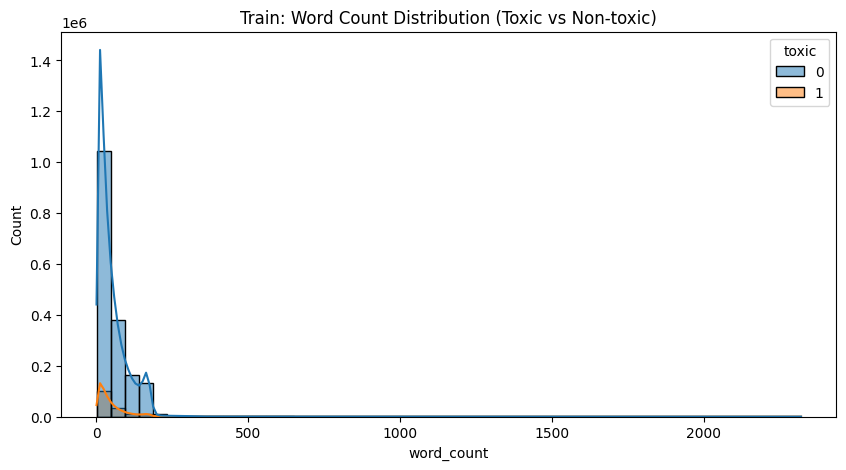

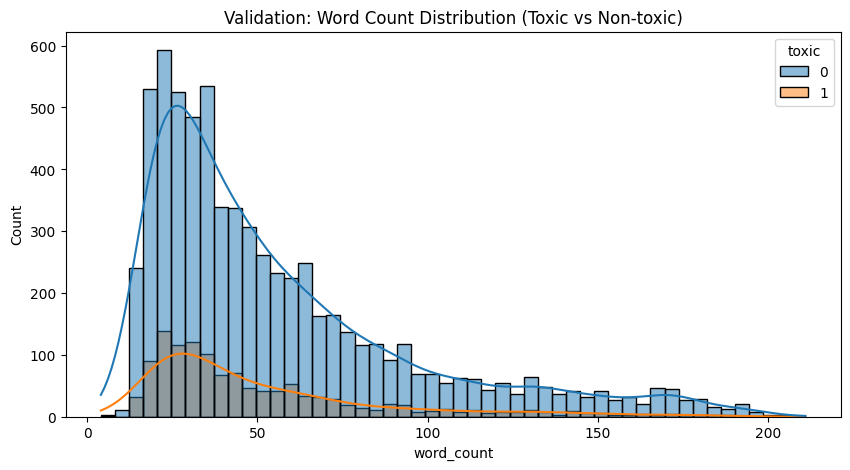

In [ ]:
# Basic Length features
print_section("Creating Text Length Features")

def add_length_features(df):
    df["char_length"] = df["comment_text"].astype(str).apply(len)
    df["word_count"] = df["comment_text"].astype(str).apply(lambda x: len(x.split()))
    return df

train_df = add_length_features(train_df)
dev_df = add_length_features(dev_df)
val_df = add_length_features(val_df)

# Length distribution (toxic vs non-toxic)
print_section("Length Distribution Analysis")

plt.figure(figsize=(10,5))
sns.histplot(data=train_df, x="word_count", hue="toxic", bins=50, kde=True)
plt.title("Train: Word Count Distribution (Toxic vs Non-toxic)")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(data=val_df, x="word_count", hue="toxic", bins=50, kde=True)
plt.title("Validation: Word Count Distribution (Toxic vs Non-toxic)")
plt.show()

**Discovery**: The distribution is right-skewed with a heavy tail, and toxic comments are slightly left-shifted.

In [ ]:
# Average length comparison
print_section("Average Length Comparison")

def length_summary(df, name):
    return pd.DataFrame({
        "dataset": [name],
        "avg_word_toxic": [df[df.toxic==1]["word_count"].mean()],
        "avg_word_non_toxic": [df[df.toxic==0]["word_count"].mean()]
    })

summary = pd.concat([
    length_summary(train_df, "train"),
    length_summary(val_df, "validation")
])

print(summary)


Average Length Comparison
      dataset  avg_word_toxic  avg_word_non_toxic
0       train       48.670808           53.665679
0  validation       50.386179           56.100015


**Discovery**: Toxic comments are symetrically shorter.

In [ ]:
# Top frequent words (toxic vs non-toxic)
print_section("Top Frequent Words")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

def get_top_words(df, label, n=20):
    texts = df[df["toxic"] == label]["comment_text"].apply(clean_text)
    words = " ".join(texts).split()
    counter = Counter(words)
    return counter.most_common(n)

top_non_toxic = get_top_words(train_df, 0)
top_toxic = get_top_words(train_df, 1)

print("\nTop Non-Toxic Words:")
print(top_non_toxic)

print("\nTop Toxic Words:")
print(top_toxic)


Top Frequent Words

Top Non-Toxic Words:
[('the', 4758529), ('to', 2673893), ('and', 2221004), ('of', 2058653), ('a', 1945843), ('is', 1525917), ('in', 1399020), ('that', 1323956), ('you', 1011245), ('i', 1010909), ('for', 958893), ('it', 948816), ('not', 738069), ('are', 724254), ('be', 659158), ('on', 644089), ('have', 625500), ('this', 621232), ('with', 578933), ('as', 560234)]

Top Toxic Words:
[('the', 327755), ('to', 195107), ('and', 189174), ('a', 175142), ('of', 150783), ('is', 133609), ('you', 132594), ('that', 95108), ('in', 93240), ('i', 80012), ('are', 73639), ('for', 68942), ('it', 66103), ('this', 53548), ('not', 50494), ('be', 46644), ('on', 46635), ('with', 46148), ('have', 45748), ('they', 45630)]


In [ ]:
# After eliminating stop words
stop_words = set(ENGLISH_STOP_WORDS)

def get_top_words_filtered(df, label, n=20):
    texts = df[df["toxic"] == label]["comment_text"].apply(clean_text)
    words = [w for w in " ".join(texts).split() if w not in stop_words]
    counter = Counter(words)
    return counter.most_common(n)

print("\nTop Toxic Words (Filtered):")
print(get_top_words_filtered(train_df, 1))

print("\nTop Non-Toxic Words (Filtered):")
print(get_top_words_filtered(train_df, 0))


Top Toxic Words (Filtered):
[('people', 28374), ('like', 28100), ('trump', 27941), ('just', 26522), ('dont', 21399), ('stupid', 15589), ('fuck', 13763), ('know', 13087), ('think', 12699), ('time', 11366), ('white', 10923), ('right', 10875), ('did', 9777), ('want', 9515), ('make', 9418), ('im', 9165), ('good', 9105), ('way', 8544), ('youre', 8358), ('really', 8300)]

Top Non-Toxic Words (Filtered):
[('people', 275809), ('just', 252676), ('like', 246477), ('dont', 216054), ('trump', 166742), ('time', 154058), ('think', 154037), ('know', 139714), ('good', 135358), ('did', 123718), ('make', 118173), ('right', 117240), ('years', 117110), ('article', 116117), ('way', 113785), ('need', 109665), ('does', 106032), ('want', 103806), ('im', 100747), ('government', 98060)]


After removing stopwords, a strong overlap in vocabulary between toxic and non-toxic comments remains. Words such as “people”, “like”, “just”, and “think” appear frequently in both classes。 This indicates most tokens are not discriminative.

However, toxic comments contain a small set of highly indicative words, such as “stupid” and “fuck”, which serve as strong signals of toxicity. These words are relatively less frequent but carry high predictive power.

In contrast, non-toxic comments do not exhibit equally strong distinguishing keywords. This suggests that classification relies more on the presence of explicit offensive language rather than distinct “non-toxic” patterns.


Train vs Validation Distribution
      dataset  positive_ratio
0       train        0.081777
1  validation        0.153769


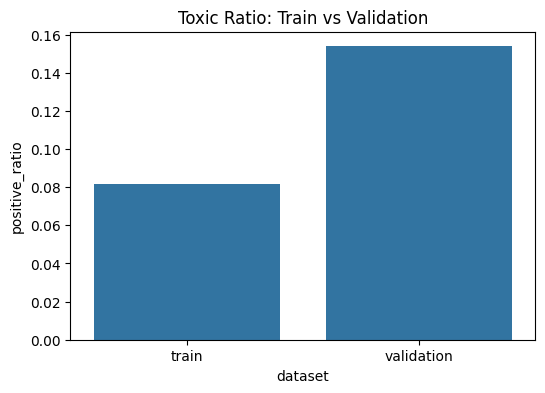

In [ ]:
# Compare Train vs Validation Distribution
print_section("Train vs Validation Distribution")

dist_df = pd.DataFrame({
    "dataset": ["train", "validation"],
    "positive_ratio": [
        train_df["toxic"].mean(),
        val_df["toxic"].mean()
    ]
})

print(dist_df)

plt.figure(figsize=(6,4))
sns.barplot(data=dist_df, x="dataset", y="positive_ratio")
plt.title("Toxic Ratio: Train vs Validation")
plt.show()

In [ ]:
# Sample Toxic Comments
print_section("Sample Toxic Comments")
print(train_df[train_df["toxic"]==1]["comment_text"].sample(3, random_state=42).tolist())

# Sample Non-toxic Comments
print_section("Sample Non-Toxic Comments")
print(train_df[train_df["toxic"]==0]["comment_text"].sample(3, random_state=42).tolist())


Sample Toxic Comments
['hello there is a special place in hell for your kind of faggotry. enjoy the ban.', "That you, in spite of the abundant information available, don't know or won't recognize that the number of uninsured drastically fell is unfortunate. Your GP's anecdotal story is sweet because that is not the position of the AMA. Lastly, that you are so self-absorbed to think that only someone who themselves got free insurance could see the benefit in eliminating pre-existing conditions and insuring 25 million more people, is pathetic.", "So, the republicans were voted in but failed to do what they promised so they fooled us once and it's shame on them because they didn't follow through. Okay, the next election the republicans were voted in and again didn't do what they were supposed to do. I would say they fooled us again, but it's our fault because we were stupid enough to trust and vote for them a second time, so now it is shame on us."]

Sample Non-Toxic Comments
['The "unde

# Module 4: Modeling

**Suggested Pipeline**:

**Module 4.1: Baseline: TF-IDF + Logistic Regression**

**WHAT** we do:
- Convert text into TF-IDF features (1–2 grams)
- Train a Logistic Regression classifier

**WHY** we choose this model:
- Toxic comments often contain clear keywords, like swear words or insults. A TF-IDF model can already capture this kind of signal quite well.
- Logistic Regression is fast and stable. It also gives us a clean reference point before trying anything more complex.
- Another reason is interpretability. We can later check which words are driving the predictions.

**Module 4.2: Neural Model: BiLSTM**

**WHAT** we do:
- Use word embeddings
- Feed sequences into a BiLSTM model
- Output toxicity probability

**WHY** we choose this model:

A BiLSTM reads the sentence as a sequence. It can capture how words interact with each other. This helps with patterns like:
- negation
- sarcasm (to some extent)
- phrase-level toxicity

Another reason is generalization.
Even if the model is trained on English, it may learn some structure that transfers better to other languages.

**WHAT** we will expect:
- We may see improvement on harder cases.
- But the gain might not be large, because toxic signals are often very explicit.
- So we need to test if extra complexity really worth it.

**Module 4.3: Transformers: mBERT + XLM-R**

**WHAT** we do:
- Fine-tune mBERT on English training data
- Fine-tune XLM-R on the same data
- Evaluate both on multilingual validation/test

**WHY** we choose these models:
1. The earlier models are not designed for multiple languages. TF-IDF depends on exact words. BiLSTM depends on embeddings trained on English. Both are limited to other languages. They are both expecte to show a very poor generalization power on the val and test datasets.
2. mBERT is trained on many languages at the same time. It maps different languages into a shared space. This means even we train the model on English data, mBERT may still understand other languages.
3. XLM-R is a stronger version of this idea. It is trained on more data and usually learns better representations. In many tasks, it performs better than mBERT.

**WHAT** we will expect:

- mBERT should already perform better than previous models on non-English data.
- XLM-R is likely the best model overall.


## 4.1 Baseline: TF-IDF + Logistic Regression

In [ ]:
# Utility Functions
def print_section(title: str) -> None:
    """Print a formatted section title."""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def evaluate_predictions(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    threshold: float = 0.5
) -> dict:
    """
    Evaluate prediction probabilities using a fixed threshold.

    Returns:
        A dictionary containing ROC-AUC, Precision, Recall, F1,
        confusion matrix, and positive prediction rate.
    """
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "positive_prediction_rate": float(np.mean(y_pred)),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist()
    }
    return metrics


def print_metrics(metrics: dict, dataset_name: str) -> None:
    """Pretty-print evaluation metrics."""
    print_section(f"{dataset_name} - Evaluation Metrics")
    print(f"Threshold: {metrics['threshold']:.2f}")
    print(f"ROC-AUC: {metrics['roc_auc']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 Score: {metrics['f1']:.4f}")
    print(f"Positive Prediction Rate: {metrics['positive_prediction_rate']:.4f}")
    print("Confusion Matrix:")
    print(np.array(metrics["confusion_matrix"]))


def evaluate_by_language(
    df: pd.DataFrame,
    prob_col: str = "pred_prob",
    label_col: str = "toxic",
    lang_col: str = "lang",
    threshold: float = 0.5
) -> pd.DataFrame:
    """
    Compute evaluation metrics for each language separately.
    """
    results = []

    for lang, group in df.groupby(lang_col):
        y_true = group[label_col].values
        y_prob = group[prob_col].values
        y_pred = (y_prob >= threshold).astype(int)

        result = {
            "lang": lang,
            "n_samples": len(group),
            "positive_ratio": group[label_col].mean(),
            "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "positive_prediction_rate": np.mean(y_pred)
        }
        results.append(result)

    return pd.DataFrame(results).sort_values(by="roc_auc", ascending=False).reset_index(drop=True)


def get_top_features(
    pipeline: Pipeline,
    top_n: int = 20
) -> tuple:
    """
    Extract top positive and top negative TF-IDF features from the trained
    logistic regression model.
    """
    vectorizer = pipeline.named_steps["tfidf"]
    model = pipeline.named_steps["clf"]

    feature_names = np.array(vectorizer.get_feature_names_out())
    coefs = model.coef_[0]

    top_positive_idx = np.argsort(coefs)[-top_n:][::-1]
    top_negative_idx = np.argsort(coefs)[:top_n]

    top_positive = pd.DataFrame({
        "feature": feature_names[top_positive_idx],
        "coefficient": coefs[top_positive_idx]
    })

    top_negative = pd.DataFrame({
        "feature": feature_names[top_negative_idx],
        "coefficient": coefs[top_negative_idx]
    })

    return top_positive, top_negative


In [ ]:
# Load prepared data
print_section("Loading Prepared Data")

DATA_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/prepared data"

train_df = pd.read_csv(f"{DATA_PATH}/train_english_train.csv")
dev_df = pd.read_csv(f"{DATA_PATH}/train_english_dev.csv")
val_df = pd.read_csv(f"{DATA_PATH}/validation_clean.csv")

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Validation shape:", val_df.shape)


Loading Prepared Data
Train shape: (1887838, 3)
Dev shape: (209760, 3)
Validation shape: (7999, 4)


In [ ]:
# Prepare inputs
print_section("Preparing Inputs")

X_train = train_df["comment_text"].astype(str).values
y_train = train_df["toxic"].astype(int).values

X_dev = dev_df["comment_text"].astype(str).values
y_dev = dev_df["toxic"].astype(int).values

X_val = val_df["comment_text"].astype(str).values
y_val = val_df["toxic"].astype(int).values

print("Training positive ratio:", round(y_train.mean(), 4))
print("Dev positive ratio:", round(y_dev.mean(), 4))
print("Validation positive ratio:", round(y_val.mean(), 4))


Preparing Inputs
Training positive ratio: 0.0818
Dev positive ratio: 0.0818
Validation positive ratio: 0.1538


In [ ]:
# Build baseline pipeline
print_section("Building TF-IDF + Logistic Regression Pipeline")

baseline_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.95,
            max_features=100000,
            sublinear_tf=True
        )
    ),
    (
        "clf",
        LogisticRegression(
            class_weight="balanced",
            solver="liblinear",
            max_iter=1000,
            random_state=42
        )
    )
])

print(baseline_pipeline)


Building TF-IDF + Logistic Regression Pipeline
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=100000, min_df=3,
                                 ngram_range=(1, 2), strip_accents='unicode',
                                 sublinear_tf=True)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42, solver='liblinear'))])


In [ ]:
# Train model
print_section("Training Baseline Model")
baseline_pipeline.fit(X_train, y_train)
print("Training completed successfully.")


Training Baseline Model
Training completed successfully.


In [ ]:
# Predict probabilities
print_section("Generating Predictions")

dev_prob = baseline_pipeline.predict_proba(X_dev)[:, 1]
val_prob = baseline_pipeline.predict_proba(X_val)[:, 1]

print("Prediction generation completed.")


Generating Predictions
Prediction generation completed.


In [ ]:
# Evaluate on English dev set
dev_metrics = evaluate_predictions(
    y_true=y_dev,
    y_prob=dev_prob,
    threshold=0.5
)

print_metrics(dev_metrics, "English Dev Set")

print_section("English Dev Set - Classification Report")
print(classification_report(y_dev, (dev_prob >= 0.5).astype(int), digits=4, zero_division=0))


English Dev Set - Evaluation Metrics
Threshold: 0.50
ROC-AUC: 0.9456
Precision: 0.4616
Recall: 0.8281
F1 Score: 0.5927
Positive Prediction Rate: 0.1467
Confusion Matrix:
[[176037  16570]
 [  2949  14204]]

English Dev Set - Classification Report
              precision    recall  f1-score   support

           0     0.9835    0.9140    0.9475    192607
           1     0.4616    0.8281    0.5927     17153

    accuracy                         0.9069    209760
   macro avg     0.7225    0.8710    0.7701    209760
weighted avg     0.9408    0.9069    0.9185    209760



In [ ]:
# Evaluate on multilingual validation set
val_metrics = evaluate_predictions(
    y_true=y_val,
    y_prob=val_prob,
    threshold=0.5
)

print_metrics(val_metrics, "Multilingual Validation Set")

print_section("Multilingual Validation Set - Classification Report")
print(classification_report(y_val, (val_prob >= 0.5).astype(int), digits=4, zero_division=0))


Multilingual Validation Set - Evaluation Metrics
Threshold: 0.50
ROC-AUC: 0.6223
Precision: 0.3924
Recall: 0.0756
F1 Score: 0.1268
Positive Prediction Rate: 0.0296
Confusion Matrix:
[[6625  144]
 [1137   93]]

Multilingual Validation Set - Classification Report
              precision    recall  f1-score   support

           0     0.8535    0.9787    0.9118      6769
           1     0.3924    0.0756    0.1268      1230

    accuracy                         0.8399      7999
   macro avg     0.6230    0.5272    0.5193      7999
weighted avg     0.7826    0.8399    0.7911      7999



In [ ]:
# Per-language evaluation on validation set
print_section("Per-Language Evaluation on Validation Set")

val_eval_df = val_df.copy()
val_eval_df["pred_prob"] = val_prob

per_lang_results = evaluate_by_language(
    df=val_eval_df,
    prob_col="pred_prob",
    label_col="toxic",
    lang_col="lang",
    threshold=0.5
)

print(per_lang_results)


Per-Language Evaluation on Validation Set
  lang  n_samples  positive_ratio   roc_auc  precision    recall        f1  \
0   tr       2999        0.106702  0.660836   0.560000  0.087500  0.151351   
1   it       2500        0.195200  0.615092   0.386364  0.034836  0.063910   
2   es       2500        0.168800  0.586452   0.335664  0.113744  0.169912   

   positive_prediction_rate  
0                  0.016672  
1                  0.017600  
2                  0.057200  


In [ ]:
# Inspect top features
print_section("Top Positive and Negative Features")

top_positive_features, top_negative_features = get_top_features(
    baseline_pipeline,
    top_n=20
)

print("Top Positive Features (associated with toxic class):")
print(top_positive_features)

print("\nTop Negative Features (associated with non-toxic class):")
print(top_negative_features)



Top Positive and Negative Features
Top Positive Features (associated with toxic class):
       feature  coefficient
0       stupid    49.420431
1       idiots    37.937425
2        idiot    36.950113
3    stupidity    35.507920
4      idiotic    30.382139
5     pathetic    29.432082
6     ignorant    28.825394
7         crap    27.994857
8         dumb    27.406899
9    hypocrite    26.872973
10  ridiculous    26.457238
11        damn    25.859994
12       fools    25.663885
13        shit    24.159069
14     foolish    24.129086
15      morons    23.910959
16       moron    23.470759
17  hypocrites    23.367008
18        fool    23.270945
19      idiocy    22.381973

Top Negative Features (associated with non-toxic class):
        feature  coefficient
0       fool me    -7.683949
1     knee jerk    -6.130786
2       to fool    -5.659956
3      can fool    -5.451304
4     give damn    -4.903262
5   ignorant of    -4.572944
6   pretty damn    -4.264640
7   white house    -4.241712
8   

In [ ]:
# Save predictions and metrics for later modules
print_section("Saving Outputs")

SAVE_BASELINE_OUTPUTS = True
OUTPUT_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/module4_outputs"

if SAVE_BASELINE_OUTPUTS:
    os.makedirs(OUTPUT_PATH, exist_ok=True)

    # Save validation predictions
    dev_output = dev_df.copy()
    dev_output["pred_prob_lr"] = dev_prob
    dev_output["pred_label_lr_05"] = (dev_prob >= 0.5).astype(int)
    dev_output.to_csv(f"{OUTPUT_PATH}/lr_dev_predictions.csv", index=False)

    val_output = val_df.copy()
    val_output["pred_prob_lr"] = val_prob
    val_output["pred_label_lr_05"] = (val_prob >= 0.5).astype(int)
    val_output.to_csv(f"{OUTPUT_PATH}/lr_validation_predictions.csv", index=False)

    # Save metrics
    metrics_dict = {
        "english_dev": dev_metrics,
        "multilingual_validation": val_metrics
    }

    with open(f"{OUTPUT_PATH}/lr_metrics.json", "w") as f:
        json.dump(metrics_dict, f, indent=4)

    per_lang_results.to_csv(f"{OUTPUT_PATH}/lr_per_language_results.csv", index=False)
    top_positive_features.to_csv(f"{OUTPUT_PATH}/lr_top_positive_features.csv", index=False)
    top_negative_features.to_csv(f"{OUTPUT_PATH}/lr_top_negative_features.csv", index=False)

    print(f"Outputs saved to: {OUTPUT_PATH}")


Saving Outputs
Outputs saved to: /content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/module4_outputs


In [ ]:
# Final summary
print_section("Module 4.1 Final Summary")

summary_table = pd.DataFrame([
    {
        "dataset": "english_dev",
        "roc_auc": round(dev_metrics["roc_auc"], 4),
        "precision": round(dev_metrics["precision"], 4),
        "recall": round(dev_metrics["recall"], 4),
        "f1": round(dev_metrics["f1"], 4),
        "positive_prediction_rate": round(dev_metrics["positive_prediction_rate"], 4)
    },
    {
        "dataset": "multilingual_validation",
        "roc_auc": round(val_metrics["roc_auc"], 4),
        "precision": round(val_metrics["precision"], 4),
        "recall": round(val_metrics["recall"], 4),
        "f1": round(val_metrics["f1"], 4),
        "positive_prediction_rate": round(val_metrics["positive_prediction_rate"], 4)
    }
])

print(summary_table)


Module 4.1 Final Summary
                   dataset  roc_auc  precision  recall      f1  \
0              english_dev   0.9456     0.4616  0.8281  0.5927   
1  multilingual_validation   0.6223     0.3924  0.0756  0.1268   

   positive_prediction_rate  
0                    0.1467  
1                    0.0296  


**Discoveries**:
- TF-IDF performs well on English dev dataset
- However, it fails to generalize its prediction power to validation set with multiple languages. Recall = .0756 meaning only 1/13 toxic comments are detected.
- Among all foreign languages, spanish is the best, while italian is the worst.
- Top positive features include many swaer words (stupid, idiot, crap, dumb, etc.)

## 4.2 BiLSTM

**Goal**: To test if context/sequence info can improve zero-shot multilingal performance.

In [ ]:
# Reproductability + Utility Functions
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

def print_section(title: str) -> None:
    """Print a formatted section title."""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def evaluate_predictions(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    threshold: float = 0.5
) -> dict:
    """
    Evaluate prediction probabilities using a fixed threshold.
    """
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "threshold": threshold,
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "positive_prediction_rate": float(np.mean(y_pred)),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist()
    }
    return metrics


def print_metrics(metrics: dict, dataset_name: str) -> None:
    """Pretty-print evaluation metrics."""
    print_section(f"{dataset_name} - Evaluation Metrics")
    print(f"Threshold: {metrics['threshold']:.2f}")
    print(f"ROC-AUC: {metrics['roc_auc']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 Score: {metrics['f1']:.4f}")
    print(f"Positive Prediction Rate: {metrics['positive_prediction_rate']:.4f}")
    print("Confusion Matrix:")
    print(np.array(metrics["confusion_matrix"]))


def evaluate_by_language(
    df: pd.DataFrame,
    prob_col: str = "pred_prob",
    label_col: str = "toxic",
    lang_col: str = "lang",
    threshold: float = 0.5
) -> pd.DataFrame:
    """
    Compute evaluation metrics for each language separately.
    """
    results = []

    for lang, group in df.groupby(lang_col):
        y_true = group[label_col].values
        y_prob = group[prob_col].values
        y_pred = (y_prob >= threshold).astype(int)

        result = {
            "lang": lang,
            "n_samples": len(group),
            "positive_ratio": float(group[label_col].mean()),
            "roc_auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else np.nan,
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, zero_division=0)),
            "positive_prediction_rate": float(np.mean(y_pred))
        }
        results.append(result)

    return pd.DataFrame(results).sort_values(by="roc_auc", ascending=False).reset_index(drop=True)


def get_class_weight_dict(y: np.ndarray) -> dict:
    """
    Create class weights for imbalanced binary classification.
    """
    n_total = len(y)
    n_pos = np.sum(y == 1)
    n_neg = np.sum(y == 0)

    weight_for_0 = n_total / (2.0 * n_neg)
    weight_for_1 = n_total / (2.0 * n_pos)

    return {
        0: float(weight_for_0),
        1: float(weight_for_1)
    }

In [ ]:
# Load prepared data
print_section("Loading Prepared Data")

DATA_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/prepared data"

train_df = pd.read_csv(f"{DATA_PATH}/train_english_train.csv")
dev_df = pd.read_csv(f"{DATA_PATH}/train_english_dev.csv")
val_df = pd.read_csv(f"{DATA_PATH}/validation_clean.csv")

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Validation shape:", val_df.shape)


Loading Prepared Data
Train shape: (1887838, 3)
Dev shape: (209760, 3)
Validation shape: (7999, 4)


In [ ]:
# Prepare text and labels
print_section("Preparing Text and Labels")

X_train_text = train_df["comment_text"].astype(str).tolist()
y_train = train_df["toxic"].astype(int).values

X_dev_text = dev_df["comment_text"].astype(str).tolist()
y_dev = dev_df["toxic"].astype(int).values

X_val_text = val_df["comment_text"].astype(str).tolist()
y_val = val_df["toxic"].astype(int).values

print("Training positive ratio:", round(y_train.mean(), 4))
print("Dev positive ratio:", round(y_dev.mean(), 4))
print("Validation positive ratio:", round(y_val.mean(), 4))


Preparing Text and Labels
Training positive ratio: 0.0818
Dev positive ratio: 0.0818
Validation positive ratio: 0.1538


In [ ]:
# Tokenization and sequence preparation
print_section("Tokenization and Sequence Preparation")

MAX_NUM_WORDS = 50000
MAX_SEQUENCE_LENGTH = 128
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(
    num_words=MAX_NUM_WORDS,
    oov_token=OOV_TOKEN
)

# Important:
# Fit tokenizer on English training data only.
# This avoids using validation information during training preparation.
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_dev_seq = tokenizer.texts_to_sequences(X_dev_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_dev_pad = pad_sequences(
    X_dev_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

vocab_size = min(MAX_NUM_WORDS, len(tokenizer.word_index) + 1)

print("Vocabulary size used:", vocab_size)
print("Train padded shape:", X_train_pad.shape)
print("Dev padded shape:", X_dev_pad.shape)
print("Validation padded shape:", X_val_pad.shape)


Tokenization and Sequence Preparation
Vocabulary size used: 50000
Train padded shape: (1887838, 128)
Dev padded shape: (209760, 128)
Validation padded shape: (7999, 128)


In [ ]:
# Build BiLSTM model
print_section("Building BiLSTM Model")

EMBEDDING_DIM = 128
LSTM_UNITS = 64
DROPOUT_RATE = 0.3
LEARNING_RATE = 1e-3

bilstm_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_SEQUENCE_LENGTH
    ),
    Bidirectional(
        LSTM(
            LSTM_UNITS,
            return_sequences=False,
            dropout=0.2,
            recurrent_dropout=0.0
        )
    ),
    Dropout(DROPOUT_RATE),
    Dense(64, activation="relu"),
    Dropout(DROPOUT_RATE),
    Dense(1, activation="sigmoid")
])

bilstm_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

bilstm_model.summary()


Building BiLSTM Model


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train model
print_section("Training BiLSTM Model")

BATCH_SIZE = 256
EPOCHS = 5

class_weight_dict = get_class_weight_dict(y_train)
print("Class weights:", class_weight_dict)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

history = bilstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_dev_pad, y_dev),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)

# Generate predictions
print_section("Generating Predictions")

dev_prob = bilstm_model.predict(X_dev_pad, batch_size=1024, verbose=1).reshape(-1)
val_prob = bilstm_model.predict(X_val_pad, batch_size=1024, verbose=1).reshape(-1)

print("Prediction generation completed.")


Training BiLSTM Model
Class weights: {0: 0.5445298037390025, 1: 6.114217423128494}
Epoch 1/5
7375/7375 ━━━━━━━━━━━━━━━━━━━━ 126s 16ms/step - accuracy: 0.8657 - loss: 0.3111 - val_accuracy: 0.8486 - val_loss: 0.3261
Epoch 2/5
7375/7375 ━━━━━━━━━━━━━━━━━━━━ 118s 16ms/step - accuracy: 0.8818 - loss: 0.2563 - val_accuracy: 0.8594 - val_loss: 0.2964
Epoch 3/5
7375/7375 ━━━━━━━━━━━━━━━━━━━━ 116s 16ms/step - accuracy: 0.8885 - loss: 0.2297 - val_accuracy: 0.8657 - val_loss: 0.2920
Epoch 4/5
7375/7375 ━━━━━━━━━━━━━━━━━━━━ 120s 16ms/step - accuracy: 0.8963 - loss: 0.2069 - val_accuracy: 0.8665 - val_loss: 0.2785
Epoch 5/5
7375/7375 ━━━━━━━━━━━━━━━━━━━━ 116s 16ms/step - accuracy: 0.9053 - loss: 0.1868 - val_accuracy: 0.8606 - val_loss: 0.3087
Restoring model weights from the end of the best epoch: 4.

Generating Predictions
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Prediction generation completed.


In [ ]:
# Evaluate on English dev set
dev_metrics = evaluate_predictions(
    y_true=y_dev,
    y_prob=dev_prob,
    threshold=0.5
)

print_metrics(dev_metrics, "English Dev Set")

print_section("English Dev Set - Classification Report")
print(classification_report(y_dev, (dev_prob >= 0.5).astype(int), digits=4, zero_division=0))


English Dev Set - Evaluation Metrics
Threshold: 0.50
ROC-AUC: 0.9482
Precision: 0.3697
Recall: 0.8968
F1 Score: 0.5236
Positive Prediction Rate: 0.1984
Confusion Matrix:
[[166383  26224]
 [  1770  15383]]

English Dev Set - Classification Report
              precision    recall  f1-score   support

           0     0.9895    0.8638    0.9224    192607
           1     0.3697    0.8968    0.5236     17153

    accuracy                         0.8665    209760
   macro avg     0.6796    0.8803    0.7230    209760
weighted avg     0.9388    0.8665    0.8898    209760



In [ ]:
# Evaluate on multilingual validation set
val_metrics = evaluate_predictions(
    y_true=y_val,
    y_prob=val_prob,
    threshold=0.5
)

print_metrics(val_metrics, "Multilingual Validation Set")

print_section("Multilingual Validation Set - Classification Report")
print(classification_report(y_val, (val_prob >= 0.5).astype(int), digits=4, zero_division=0))


Multilingual Validation Set - Evaluation Metrics
Threshold: 0.50
ROC-AUC: 0.5679
Precision: 0.2587
Recall: 0.2057
F1 Score: 0.2292
Positive Prediction Rate: 0.1223
Confusion Matrix:
[[6044  725]
 [ 977  253]]

Multilingual Validation Set - Classification Report
              precision    recall  f1-score   support

           0     0.8608    0.8929    0.8766      6769
           1     0.2587    0.2057    0.2292      1230

    accuracy                         0.7872      7999
   macro avg     0.5598    0.5493    0.5529      7999
weighted avg     0.7683    0.7872    0.7770      7999



In [ ]:
# Per-language evaluation on validation set
print_section("Per-Language Evaluation on Validation Set")

val_eval_df = val_df.copy()
val_eval_df["pred_prob"] = val_prob

per_lang_results = evaluate_by_language(
    df=val_eval_df,
    prob_col="pred_prob",
    label_col="toxic",
    lang_col="lang",
    threshold=0.5
)

print(per_lang_results)


Per-Language Evaluation on Validation Set
  lang  n_samples  positive_ratio   roc_auc  precision    recall        f1  \
0   es       2500        0.168800  0.641660   0.266402  0.317536  0.289730   
1   tr       2999        0.106702  0.557773   0.286957  0.103125  0.151724   
2   it       2500        0.195200  0.524580   0.238889  0.176230  0.202830   

   positive_prediction_rate  
0                  0.201200  
1                  0.038346  
2                  0.144000  


In [ ]:
# Save outputs for later modules
print_section("Saving Outputs")

SAVE_BILSTM_OUTPUTS = True
OUTPUT_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/module4_outputs"

if SAVE_BILSTM_OUTPUTS:
    os.makedirs(OUTPUT_PATH, exist_ok=True)

    dev_output = dev_df.copy()
    dev_output["pred_prob_bilstm"] = dev_prob
    dev_output["pred_label_bilstm_05"] = (dev_prob >= 0.5).astype(int)
    dev_output.to_csv(f"{OUTPUT_PATH}/bilstm_dev_predictions.csv", index=False)

    val_output = val_df.copy()
    val_output["pred_prob_bilstm"] = val_prob
    val_output["pred_label_bilstm_05"] = (val_prob >= 0.5).astype(int)
    val_output.to_csv(f"{OUTPUT_PATH}/bilstm_validation_predictions.csv", index=False)

    metrics_dict = {
        "english_dev": dev_metrics,
        "multilingual_validation": val_metrics
    }

    with open(f"{OUTPUT_PATH}/bilstm_metrics.json", "w") as f:
        json.dump(metrics_dict, f, indent=4)

    per_lang_results.to_csv(f"{OUTPUT_PATH}/bilstm_per_language_results.csv", index=False)

    print(f"Outputs saved to: {OUTPUT_PATH}")


Saving Outputs
Outputs saved to: /content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/module4_outputs


In [ ]:
# Final summary
print_section("Module 4.2 Final Summary")

summary_table = pd.DataFrame([
    {
        "dataset": "english_dev",
        "roc_auc": round(dev_metrics["roc_auc"], 4),
        "precision": round(dev_metrics["precision"], 4),
        "recall": round(dev_metrics["recall"], 4),
        "f1": round(dev_metrics["f1"], 4),
        "positive_prediction_rate": round(dev_metrics["positive_prediction_rate"], 4)
    },
    {
        "dataset": "multilingual_validation",
        "roc_auc": round(val_metrics["roc_auc"], 4),
        "precision": round(val_metrics["precision"], 4),
        "recall": round(val_metrics["recall"], 4),
        "f1": round(val_metrics["f1"], 4),
        "positive_prediction_rate": round(val_metrics["positive_prediction_rate"], 4)
    }
])

print(summary_table)


Module 4.2 Final Summary
                   dataset  roc_auc  precision  recall      f1  \
0              english_dev   0.9482     0.3697  0.8968  0.5236   
1  multilingual_validation   0.5679     0.2587  0.2057  0.2292   

   positive_prediction_rate  
0                    0.1984  
1                    0.1223  


## 4.3 Transformer-based models

### 4.3.1 mBERT (Please take the **DEBUG** version, ignore this one)

In [ ]:
# Reproductability & Utility Functions
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
def print_section(title: str) -> None:
    """Print a formatted section title."""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def evaluate_predictions(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    threshold: float = 0.5
) -> dict:
    """
    Evaluate prediction probabilities using a fixed threshold.
    """
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "threshold": threshold,
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "positive_prediction_rate": float(np.mean(y_pred)),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist()
    }
    return metrics


def print_metrics(metrics: dict, dataset_name: str) -> None:
    """Pretty-print evaluation metrics."""
    print_section(f"{dataset_name} - Evaluation Metrics")
    print(f"Threshold: {metrics['threshold']:.2f}")
    print(f"ROC-AUC: {metrics['roc_auc']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 Score: {metrics['f1']:.4f}")
    print(f"Positive Prediction Rate: {metrics['positive_prediction_rate']:.4f}")
    print("Confusion Matrix:")
    print(np.array(metrics["confusion_matrix"]))


def evaluate_by_language(
    df: pd.DataFrame,
    prob_col: str = "pred_prob",
    label_col: str = "toxic",
    lang_col: str = "lang",
    threshold: float = 0.5
) -> pd.DataFrame:
    """
    Compute evaluation metrics for each language separately.
    """
    results = []

    for lang, group in df.groupby(lang_col):
        y_true = group[label_col].values
        y_prob = group[prob_col].values
        y_pred = (y_prob >= threshold).astype(int)

        result = {
            "lang": lang,
            "n_samples": len(group),
            "positive_ratio": float(group[label_col].mean()),
            "roc_auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else np.nan,
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, zero_division=0)),
            "positive_prediction_rate": float(np.mean(y_pred))
        }
        results.append(result)

    return pd.DataFrame(results).sort_values(by="roc_auc", ascending=False).reset_index(drop=True)


def sigmoid_numpy(x: np.ndarray) -> np.ndarray:
    """Apply sigmoid to logits."""
    return 1.0 / (1.0 + np.exp(-x))



In [ ]:
# Load prepared data
print_section("Loading Prepared Data")

DATA_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/prepared data"

train_df = pd.read_csv(f"{DATA_PATH}/train_english_train.csv")
dev_df = pd.read_csv(f"{DATA_PATH}/train_english_dev.csv")
val_df = pd.read_csv(f"{DATA_PATH}/validation_clean.csv")

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Validation shape:", val_df.shape)

# Optional sampling for faster experimentation
USE_FAST_DEBUG = False

if USE_FAST_DEBUG:
    train_df = train_df.sample(frac=0.1, random_state=SEED).reset_index(drop=True)
    dev_df = dev_df.sample(frac=0.2, random_state=SEED).reset_index(drop=True)
    val_df = val_df.sample(frac=0.2, random_state=SEED).reset_index(drop=True)

print("Final train shape:", train_df.shape)
print("Final dev shape:", dev_df.shape)
print("Final validation shape:", val_df.shape)


Loading Prepared Data
Train shape: (1887838, 3)
Dev shape: (209760, 3)
Validation shape: (7999, 4)
Final train shape: (1887838, 3)
Final dev shape: (209760, 3)
Final validation shape: (7999, 4)


In [ ]:
# Prepare Hugging Face datasets
print_section("Preparing Datasets")

train_df = train_df[["comment_text", "toxic"]].copy()
dev_df = dev_df[["comment_text", "toxic"]].copy()
val_df = val_df[["comment_text", "toxic", "lang"]].copy()

train_df["label"] = train_df["toxic"].astype(int)
dev_df["label"] = dev_df["toxic"].astype(int)
val_df["label"] = val_df["toxic"].astype(int)

train_dataset = Dataset.from_pandas(train_df[["comment_text", "label"]], preserve_index=False)
dev_dataset = Dataset.from_pandas(dev_df[["comment_text", "label"]], preserve_index=False)
val_dataset = Dataset.from_pandas(val_df[["comment_text", "label", "lang"]], preserve_index=False)

print(train_dataset)
print(dev_dataset)
print(val_dataset)


Preparing Datasets
Dataset({
    features: ['comment_text', 'label'],
    num_rows: 1887838
})
Dataset({
    features: ['comment_text', 'label'],
    num_rows: 209760
})
Dataset({
    features: ['comment_text', 'label', 'lang'],
    num_rows: 7999
})


In [ ]:
# Tokenizer and tokenization
print_section("Loading Tokenizer")

MODEL_NAME = "bert-base-multilingual-cased"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(
        batch["comment_text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
dev_dataset = dev_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)



Loading Tokenizer


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1887838 [00:00<?, ? examples/s]

Map:   0%|          | 0/209760 [00:00<?, ? examples/s]

Map:   0%|          | 0/7999 [00:00<?, ? examples/s]

In [ ]:
# Class weights for imbalanced training
print_section("Computing Class Weights")

train_labels = train_df["label"].values
n_total = len(train_labels)
n_pos = np.sum(train_labels == 1)
n_neg = np.sum(train_labels == 0)

weight_for_0 = n_total / (2.0 * n_neg)
weight_for_1 = n_total / (2.0 * n_pos)

class_weights = torch.tensor([weight_for_0, weight_for_1], dtype=torch.float)

print("Class weights:", class_weights.tolist())



Computing Class Weights
Class weights: [0.5445297956466675, 6.114217281341553]


In [ ]:
# Custom Trainer with weighted loss
print_section("Building Model")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=1,
    problem_type="single_label_classification"
)

class WeightedBCETrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels").float()
        outputs = model(**inputs)
        logits = outputs.logits.view(-1)

        loss_fn = torch.nn.BCEWithLogitsLoss(
            pos_weight=class_weights[1].to(logits.device)
        )
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss


Building Model


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Training arguments
print_section("Setting Training Arguments")

OUTPUT_DIR = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/module4_outputs/mbert_model"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    # Core training setup
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,

    # Evaluation / saving
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,

    # Logging
    logging_dir=f"{OUTPUT_DIR}/logs",
    logging_steps=100,

    # Runtime
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



Setting Training Arguments


In [ ]:
# Build trainer
print_section("Initializing Trainer")

trainer = WeightedBCETrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

# Train model
print_section("Training mBERT")
trainer.train()
print("Training completed successfully.")


Initializing Trainer

Training mBERT


Epoch,Training Loss,Validation Loss
1,1.021666,0.928546
2,0.849709,0.927772


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Training completed successfully.


In [ ]:
# Predict on English dev
print_section("Predicting on English Dev Set")

dev_predictions = trainer.predict(dev_dataset)
dev_logits = dev_predictions.predictions.reshape(-1)
dev_prob = sigmoid_numpy(dev_logits)
print("dev_logits summary:")
print("min:", np.min(dev_logits))
print("max:", np.max(dev_logits))
print("mean:", np.mean(dev_logits))
print("std:", np.std(dev_logits))

print("\ndev_prob summary:")
print("min:", np.min(dev_prob))
print("max:", np.max(dev_prob))
print("mean:", np.mean(dev_prob))
print("std:", np.std(dev_prob))

print("\nFirst 20 dev_prob:")
print(dev_prob[:20])
y_dev = dev_df["label"].values

dev_metrics = evaluate_predictions(
    y_true=y_dev,
    y_prob=dev_prob,
    threshold=0.5
)

print_metrics(dev_metrics, "English Dev Set")

print_section("English Dev Set - Classification Report")
print(classification_report(y_dev, (dev_prob >= 0.5).astype(int), digits=4, zero_division=0))


Predicting on English Dev Set


Epoch,Training Loss,Validation Loss


dev_logits summary:
min: -0.81103516
max: -0.8105469
mean: -0.8105511
std: 4.5148903e-05

dev_prob summary:
min: 0.30766994
max: 0.30777398
mean: 0.3077731
std: 9.620101e-06

First 20 dev_prob:
[0.30777398 0.30777398 0.30777398 0.30777398 0.30777398 0.30777398
 0.30777398 0.30777398 0.30777398 0.30777398 0.30777398 0.30777398
 0.30777398 0.30777398 0.30777398 0.30777398 0.30777398 0.30777398
 0.30777398 0.30777398]

English Dev Set - Evaluation Metrics
Threshold: 0.50
ROC-AUC: 0.5000
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
Positive Prediction Rate: 0.0000
Confusion Matrix:
[[192607      0]
 [ 17153      0]]

English Dev Set - Classification Report
              precision    recall  f1-score   support

           0     0.9182    1.0000    0.9574    192607
           1     0.0000    0.0000    0.0000     17153

    accuracy                         0.9182    209760
   macro avg     0.4591    0.5000    0.4787    209760
weighted avg     0.8431    0.9182    0.8791    209760



In [ ]:
# Predict on multilingual validation
print_section("Predicting on Multilingual Validation Set")

val_predictions = trainer.predict(val_dataset)
val_logits = val_predictions.predictions.reshape(-1)
val_prob = sigmoid_numpy(val_logits)
y_val = val_df["label"].values

val_metrics = evaluate_predictions(
    y_true=y_val,
    y_prob=val_prob,
    threshold=0.5
)

print_metrics(val_metrics, "Multilingual Validation Set")

print_section("Multilingual Validation Set - Classification Report")
print(classification_report(y_val, (val_prob >= 0.5).astype(int), digits=4, zero_division=0))


Predicting on Multilingual Validation Set



Multilingual Validation Set - Evaluation Metrics
Threshold: 0.50
ROC-AUC: 0.5000
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
Positive Prediction Rate: 0.0000
Confusion Matrix:
[[6769    0]
 [1230    0]]

Multilingual Validation Set - Classification Report
              precision    recall  f1-score   support

           0     0.8462    1.0000    0.9167      6769
           1     0.0000    0.0000    0.0000      1230

    accuracy                         0.8462      7999
   macro avg     0.4231    0.5000    0.4584      7999
weighted avg     0.7161    0.8462    0.7757      7999



In [ ]:
# Per-language evaluation on validation set
print_section("Per-Language Evaluation on Validation Set")

val_eval_df = val_df.copy()
val_eval_df["pred_prob"] = val_prob

per_lang_results = evaluate_by_language(
    df=val_eval_df,
    prob_col="pred_prob",
    label_col="toxic",
    lang_col="lang",
    threshold=0.5
)

print(per_lang_results)


Per-Language Evaluation on Validation Set
  lang  n_samples  positive_ratio  roc_auc  precision  recall   f1  \
0   es       2500        0.168800      0.5        0.0     0.0  0.0   
1   it       2500        0.195200      0.5        0.0     0.0  0.0   
2   tr       2999        0.106702      0.5        0.0     0.0  0.0   

   positive_prediction_rate  
0                       0.0  
1                       0.0  
2                       0.0  


In [ ]:
# Save outputs for later modules
print_section("Saving Outputs")

SAVE_MBERT_OUTPUTS = True
OUTPUT_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/module4_outputs"

if SAVE_MBERT_OUTPUTS:
    os.makedirs(OUTPUT_PATH, exist_ok=True)

    # Save trained model and tokenizer
    trainer.save_model(f"{OUTPUT_PATH}/mbert_best_model")
    tokenizer.save_pretrained(f"{OUTPUT_PATH}/mbert_best_model")

    # Save dev predictions
    dev_output = dev_df.copy()
    dev_output["pred_prob_mbert"] = dev_prob
    dev_output["pred_label_mbert_05"] = (dev_prob >= 0.5).astype(int)
    dev_output.to_csv(f"{OUTPUT_PATH}/mbert_dev_predictions.csv", index=False)

    # Save validation predictions
    val_output = val_df.copy()
    val_output["pred_prob_mbert"] = val_prob
    val_output["pred_label_mbert_05"] = (val_prob >= 0.5).astype(int)
    val_output.to_csv(f"{OUTPUT_PATH}/mbert_validation_predictions.csv", index=False)

    # Save metrics
    metrics_dict = {
        "english_dev": dev_metrics,
        "multilingual_validation": val_metrics
    }

    with open(f"{OUTPUT_PATH}/mbert_metrics.json", "w") as f:
        json.dump(metrics_dict, f, indent=4)

    per_lang_results.to_csv(f"{OUTPUT_PATH}/mbert_per_language_results.csv", index=False)

    print(f"Outputs saved to: {OUTPUT_PATH}")


Saving Outputs


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Outputs saved to: /content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/module4_outputs


In [ ]:
# Final summary
print_section("Module 4.3.1 Final Summary")

summary_table = pd.DataFrame([
    {
        "dataset": "english_dev",
        "roc_auc": round(dev_metrics["roc_auc"], 4),
        "precision": round(dev_metrics["precision"], 4),
        "recall": round(dev_metrics["recall"], 4),
        "f1": round(dev_metrics["f1"], 4),
        "positive_prediction_rate": round(dev_metrics["positive_prediction_rate"], 4)
    },
    {
        "dataset": "multilingual_validation",
        "roc_auc": round(val_metrics["roc_auc"], 4),
        "precision": round(val_metrics["precision"], 4),
        "recall": round(val_metrics["recall"], 4),
        "f1": round(val_metrics["f1"], 4),
        "positive_prediction_rate": round(val_metrics["positive_prediction_rate"], 4)
    }
])

print(summary_table)


Module 4.3.1 Final Summary
                   dataset  roc_auc  precision  recall   f1  \
0              english_dev      0.5        0.0     0.0  0.0   
1  multilingual_validation      0.5        0.0     0.0  0.0   

   positive_prediction_rate  
0                       0.0  
1                       0.0  


#### Debug

In [ ]:
# ============================================================
# Module 4.3.1: Core Model 1
# mBERT (2-class stable version) for Zero-Shot Cross-Lingual Toxic Comment Detection
# ============================================================

# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# 2. Utility functions
# ------------------------------------------------------------
def print_section(title: str) -> None:
    """Print a formatted section title."""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def evaluate_predictions(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    threshold: float = 0.5
) -> dict:
    """
    Evaluate prediction probabilities using a fixed threshold.
    """
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "threshold": threshold,
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "positive_prediction_rate": float(np.mean(y_pred)),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist()
    }
    return metrics


def print_metrics(metrics: dict, dataset_name: str) -> None:
    """Pretty-print evaluation metrics."""
    print_section(f"{dataset_name} - Evaluation Metrics")
    print(f"Threshold: {metrics['threshold']:.2f}")
    print(f"ROC-AUC: {metrics['roc_auc']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 Score: {metrics['f1']:.4f}")
    print(f"Positive Prediction Rate: {metrics['positive_prediction_rate']:.4f}")
    print("Confusion Matrix:")
    print(np.array(metrics["confusion_matrix"]))


def evaluate_by_language(
    df: pd.DataFrame,
    prob_col: str = "pred_prob",
    label_col: str = "toxic",
    lang_col: str = "lang",
    threshold: float = 0.5
) -> pd.DataFrame:
    """
    Compute evaluation metrics for each language separately.
    """
    results = []

    for lang, group in df.groupby(lang_col):
        y_true = group[label_col].values
        y_prob = group[prob_col].values
        y_pred = (y_prob >= threshold).astype(int)

        result = {
            "lang": lang,
            "n_samples": len(group),
            "positive_ratio": float(group[label_col].mean()),
            "roc_auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else np.nan,
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, zero_division=0)),
            "positive_prediction_rate": float(np.mean(y_pred))
        }
        results.append(result)

    return pd.DataFrame(results).sort_values(by="roc_auc", ascending=False).reset_index(drop=True)



In [ ]:
# ------------------------------------------------------------
# 3. Load prepared data
# ------------------------------------------------------------
print_section("Loading Prepared Data")

DATA_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/prepared data"

train_df = pd.read_csv(f"{DATA_PATH}/train_english_train.csv")
dev_df = pd.read_csv(f"{DATA_PATH}/train_english_dev.csv")
val_df = pd.read_csv(f"{DATA_PATH}/validation_clean.csv")

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Validation shape:", val_df.shape)


# ------------------------------------------------------------
# 4. Optional sampling for faster experimentation
# ------------------------------------------------------------
# Set USE_FAST_DEBUG = True if you want a smaller run first.
# For the real run, keep it False.

USE_FAST_DEBUG = False

if USE_FAST_DEBUG:
    train_df = train_df.sample(frac=0.1, random_state=SEED).reset_index(drop=True)
    dev_df = dev_df.sample(frac=0.2, random_state=SEED).reset_index(drop=True)
    val_df = val_df.sample(frac=0.2, random_state=SEED).reset_index(drop=True)

print("Final train shape:", train_df.shape)
print("Final dev shape:", dev_df.shape)
print("Final validation shape:", val_df.shape)


# ------------------------------------------------------------
# 5. Prepare Hugging Face datasets
# ------------------------------------------------------------
print_section("Preparing Datasets")

train_df = train_df[["comment_text", "toxic"]].copy()
dev_df = dev_df[["comment_text", "toxic"]].copy()
val_df = val_df[["comment_text", "toxic", "lang"]].copy()

train_df["label"] = train_df["toxic"].astype(int)
dev_df["label"] = dev_df["toxic"].astype(int)
val_df["label"] = val_df["toxic"].astype(int)

train_dataset = Dataset.from_pandas(train_df[["comment_text", "label"]], preserve_index=False)
dev_dataset = Dataset.from_pandas(dev_df[["comment_text", "label"]], preserve_index=False)
val_dataset = Dataset.from_pandas(val_df[["comment_text", "label", "lang"]], preserve_index=False)

print(train_dataset)
print(dev_dataset)
print(val_dataset)





Loading Prepared Data
Train shape: (1887838, 3)
Dev shape: (209760, 3)
Validation shape: (7999, 4)
Final train shape: (1887838, 3)
Final dev shape: (209760, 3)
Final validation shape: (7999, 4)

Preparing Datasets
Dataset({
    features: ['comment_text', 'label'],
    num_rows: 1887838
})
Dataset({
    features: ['comment_text', 'label'],
    num_rows: 209760
})
Dataset({
    features: ['comment_text', 'label', 'lang'],
    num_rows: 7999
})


In [ ]:
# ------------------------------------------------------------
# 6. Tokenizer and tokenization
# ------------------------------------------------------------
print_section("Loading Tokenizer")

MODEL_NAME = "bert-base-multilingual-cased"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(
        batch["comment_text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
dev_dataset = dev_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)





Loading Tokenizer


Map:   0%|          | 0/1887838 [00:00<?, ? examples/s]

Map:   0%|          | 0/209760 [00:00<?, ? examples/s]

Map:   0%|          | 0/7999 [00:00<?, ? examples/s]

In [ ]:
# ------------------------------------------------------------
# 7. Class weights for imbalanced training
# ------------------------------------------------------------
print_section("Computing Class Weights")

train_labels = train_df["label"].values
n_total = len(train_labels)
n_pos = np.sum(train_labels == 1)
n_neg = np.sum(train_labels == 0)

weight_for_0 = n_total / (2.0 * n_neg)
weight_for_1 = n_total / (2.0 * n_pos)

class_weights = torch.tensor([weight_for_0, weight_for_1], dtype=torch.float)

print("Class weights:", class_weights.tolist())





Computing Class Weights
Class weights: [0.5445297956466675, 6.114217281341553]


In [ ]:
# ------------------------------------------------------------
# 8. Custom Trainer with weighted cross entropy
# ------------------------------------------------------------
print_section("Building Model")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

class WeightedCETrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels").long()
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fn = torch.nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device)
        )
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss





Building Model


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# ------------------------------------------------------------
# 9. Training arguments
# ------------------------------------------------------------
print_section("Setting Training Arguments")

OUTPUT_DIR = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/module4_outputs/mbert_model"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    # Core training setup
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,

    # Evaluation / saving
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,

    # Logging
    logging_dir=f"{OUTPUT_DIR}/logs",
    logging_steps=100,

    # Runtime
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED
)




`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



Setting Training Arguments


In [ ]:
# ------------------------------------------------------------
# 10. Build trainer
# ------------------------------------------------------------
print_section("Initializing Trainer")

trainer = WeightedCETrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)


# ------------------------------------------------------------
# 11. Train model
# ------------------------------------------------------------
print_section("Training mBERT")

trainer.train()

print("Training completed successfully.")





Initializing Trainer

Training mBERT


Epoch,Training Loss,Validation Loss
1,0.720922,0.690196
2,0.380825,0.594402


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Training completed successfully.


In [ ]:
# ------------------------------------------------------------
# 12. Predict on English Dev
# ------------------------------------------------------------
print_section("Predicting on English Dev Set")

dev_predictions = trainer.predict(dev_dataset)
dev_logits = dev_predictions.predictions

# Convert 2-class logits into probability of class 1
dev_prob = F.softmax(torch.tensor(dev_logits), dim=1).numpy()[:, 1]
y_dev = dev_df["label"].values

# Optional debug check
print("dev_logits summary:")
print("min:", np.min(dev_logits))
print("max:", np.max(dev_logits))
print("mean:", np.mean(dev_logits))
print("std:", np.std(dev_logits))

print("\ndev_prob summary:")
print("min:", np.min(dev_prob))
print("max:", np.max(dev_prob))
print("mean:", np.mean(dev_prob))
print("std:", np.std(dev_prob))

print("\nFirst 20 dev_prob:")
print(dev_prob[:20])

dev_metrics = evaluate_predictions(
    y_true=y_dev,
    y_prob=dev_prob,
    threshold=0.5
)

print_metrics(dev_metrics, "English Dev Set")

print_section("English Dev Set - Classification Report")
print(classification_report(y_dev, (dev_prob >= 0.5).astype(int), digits=4, zero_division=0))





Predicting on English Dev Set


dev_logits summary:
min: -2.6289062
max: 2.6914062
mean: 0.06321109
std: 2.2728796

dev_prob summary:
min: 0.0054692742
max: 0.98774695
mean: 0.10183974
std: 0.26043025

First 20 dev_prob:
[0.00569696 0.00573025 0.0085113  0.00552265 0.01994693 0.00637594
 0.00571913 0.02615562 0.98760426 0.00891613 0.25196967 0.00765103
 0.00717688 0.00900284 0.453761   0.01009132 0.00950408 0.00997492
 0.00932197 0.01264932]

English Dev Set - Evaluation Metrics
Threshold: 0.50
ROC-AUC: 0.8818
Precision: 0.6006
Recall: 0.6681
F1 Score: 0.6325
Positive Prediction Rate: 0.0910
Confusion Matrix:
[[184985   7622]
 [  5693  11460]]

English Dev Set - Classification Report
              precision    recall  f1-score   support

           0     0.9701    0.9604    0.9653    192607
           1     0.6006    0.6681    0.6325     17153

    accuracy                         0.9365    209760
   macro avg     0.7854    0.8143    0.7989    209760
weighted avg     0.9399    0.9365    0.9381    209760



In [ ]:
# ------------------------------------------------------------
# 13. Predict on multilingual validation
# ------------------------------------------------------------
print_section("Predicting on Multilingual Validation Set")

val_predictions = trainer.predict(val_dataset)
val_logits = val_predictions.predictions
val_prob = F.softmax(torch.tensor(val_logits), dim=1).numpy()[:, 1]
y_val = val_df["label"].values

val_metrics = evaluate_predictions(
    y_true=y_val,
    y_prob=val_prob,
    threshold=0.5
)

print_metrics(val_metrics, "Multilingual Validation Set")

print_section("Multilingual Validation Set - Classification Report")
print(classification_report(y_val, (val_prob >= 0.5).astype(int), digits=4, zero_division=0))





Predicting on Multilingual Validation Set



Multilingual Validation Set - Evaluation Metrics
Threshold: 0.50
ROC-AUC: 0.7259
Precision: 0.4150
Recall: 0.2480
F1 Score: 0.3104
Positive Prediction Rate: 0.0919
Confusion Matrix:
[[6339  430]
 [ 925  305]]

Multilingual Validation Set - Classification Report
              precision    recall  f1-score   support

           0     0.8727    0.9365    0.9034      6769
           1     0.4150    0.2480    0.3104      1230

    accuracy                         0.8306      7999
   macro avg     0.6438    0.5922    0.6069      7999
weighted avg     0.8023    0.8306    0.8123      7999



In [ ]:
# ------------------------------------------------------------
# 14. Per-language evaluation on validation set
# ------------------------------------------------------------
print_section("Per-Language Evaluation on Validation Set")

val_eval_df = val_df.copy()
val_eval_df["pred_prob"] = val_prob

per_lang_results = evaluate_by_language(
    df=val_eval_df,
    prob_col="pred_prob",
    label_col="toxic",
    lang_col="lang",
    threshold=0.5
)

print(per_lang_results)





Per-Language Evaluation on Validation Set
  lang  n_samples  positive_ratio   roc_auc  precision    recall        f1  \
0   es       2500        0.168800  0.758660   0.462783  0.338863  0.391245   
1   tr       2999        0.106702  0.727161   0.369231  0.150000  0.213333   
2   it       2500        0.195200  0.682291   0.385135  0.233607  0.290816   

   positive_prediction_rate  
0                  0.123600  
1                  0.043348  
2                  0.118400  


In [ ]:
# ------------------------------------------------------------
# 15. Save outputs for later modules
# ------------------------------------------------------------
print_section("Saving Outputs")

SAVE_MBERT_OUTPUTS = True
OUTPUT_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/module4_outputs"

if SAVE_MBERT_OUTPUTS:
    os.makedirs(OUTPUT_PATH, exist_ok=True)

    # Save trained model
    trainer.save_model(f"{OUTPUT_PATH}/mbert_best_model")
    tokenizer.save_pretrained(f"{OUTPUT_PATH}/mbert_best_model")

    # Save dev predictions
    dev_output = dev_df.copy()
    dev_output["pred_prob_mbert"] = dev_prob
    dev_output["pred_label_mbert_05"] = (dev_prob >= 0.5).astype(int)
    dev_output.to_csv(f"{OUTPUT_PATH}/mbert_dev_predictions.csv", index=False)

    # Save validation predictions
    val_output = val_df.copy()
    val_output["pred_prob_mbert"] = val_prob
    val_output["pred_label_mbert_05"] = (val_prob >= 0.5).astype(int)
    val_output.to_csv(f"{OUTPUT_PATH}/mbert_validation_predictions.csv", index=False)

    # Save metrics
    metrics_dict = {
        "english_dev": dev_metrics,
        "multilingual_validation": val_metrics
    }

    with open(f"{OUTPUT_PATH}/mbert_metrics.json", "w") as f:
        json.dump(metrics_dict, f, indent=4)

    per_lang_results.to_csv(f"{OUTPUT_PATH}/mbert_per_language_results.csv", index=False)

    print(f"Outputs saved to: {OUTPUT_PATH}")





Saving Outputs


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Outputs saved to: /content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/module4_outputs


In [ ]:
# ------------------------------------------------------------
# 16. Final summary
# ------------------------------------------------------------
print_section("Module 4.3.1 Final Summary")

summary_table = pd.DataFrame([
    {
        "dataset": "english_dev",
        "roc_auc": round(dev_metrics["roc_auc"], 4),
        "precision": round(dev_metrics["precision"], 4),
        "recall": round(dev_metrics["recall"], 4),
        "f1": round(dev_metrics["f1"], 4),
        "positive_prediction_rate": round(dev_metrics["positive_prediction_rate"], 4)
    },
    {
        "dataset": "multilingual_validation",
        "roc_auc": round(val_metrics["roc_auc"], 4),
        "precision": round(val_metrics["precision"], 4),
        "recall": round(val_metrics["recall"], 4),
        "f1": round(val_metrics["f1"], 4),
        "positive_prediction_rate": round(val_metrics["positive_prediction_rate"], 4)
    }
])

print(summary_table)


Module 4.3.1 Final Summary
                   dataset  roc_auc  precision  recall      f1  \
0              english_dev   0.8818     0.6006  0.6681  0.6325   
1  multilingual_validation   0.7259     0.4150  0.2480  0.3104   

   positive_prediction_rate  
0                    0.0910  
1                    0.0919  


### 4.3.2 XLM-R (Please take the DEBUG version, ignore this one)

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
def print_section(title: str) -> None:
    """Print a formatted section title."""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def evaluate_predictions(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    threshold: float = 0.5
) -> dict:
    """
    Evaluate prediction probabilities using a fixed threshold.
    """
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "threshold": threshold,
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "positive_prediction_rate": float(np.mean(y_pred)),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist()
    }
    return metrics


def print_metrics(metrics: dict, dataset_name: str) -> None:
    """Pretty-print evaluation metrics."""
    print_section(f"{dataset_name} - Evaluation Metrics")
    print(f"Threshold: {metrics['threshold']:.2f}")
    print(f"ROC-AUC: {metrics['roc_auc']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 Score: {metrics['f1']:.4f}")
    print(f"Positive Prediction Rate: {metrics['positive_prediction_rate']:.4f}")
    print("Confusion Matrix:")
    print(np.array(metrics["confusion_matrix"]))


def evaluate_by_language(
    df: pd.DataFrame,
    prob_col: str = "pred_prob",
    label_col: str = "toxic",
    lang_col: str = "lang",
    threshold: float = 0.5
) -> pd.DataFrame:
    """
    Compute evaluation metrics for each language separately.
    """
    results = []

    for lang, group in df.groupby(lang_col):
        y_true = group[label_col].values
        y_prob = group[prob_col].values
        y_pred = (y_prob >= threshold).astype(int)

        result = {
            "lang": lang,
            "n_samples": len(group),
            "positive_ratio": float(group[label_col].mean()),
            "roc_auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else np.nan,
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, zero_division=0)),
            "positive_prediction_rate": float(np.mean(y_pred))
        }
        results.append(result)

    return pd.DataFrame(results).sort_values(by="roc_auc", ascending=False).reset_index(drop=True)


def sigmoid_numpy(x: np.ndarray) -> np.ndarray:
    """Apply sigmoid to logits."""
    return 1.0 / (1.0 + np.exp(-x))


In [ ]:
# Load prepared data
print_section("Loading Prepared Data")

DATA_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/prepared data"

train_df = pd.read_csv(f"{DATA_PATH}/train_english_train.csv")
dev_df = pd.read_csv(f"{DATA_PATH}/train_english_dev.csv")
val_df = pd.read_csv(f"{DATA_PATH}/validation_clean.csv")

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Validation shape:", val_df.shape)

# Optional sampling for faster experimentation
USE_FAST_DEBUG = False

if USE_FAST_DEBUG:
    train_df = train_df.sample(frac=0.1, random_state=SEED).reset_index(drop=True)
    dev_df = dev_df.sample(frac=0.2, random_state=SEED).reset_index(drop=True)
    val_df = val_df.sample(frac=0.2, random_state=SEED).reset_index(drop=True)

print("Final train shape:", train_df.shape)
print("Final dev shape:", dev_df.shape)
print("Final validation shape:", val_df.shape)


Loading Prepared Data
Train shape: (1887838, 3)
Dev shape: (209760, 3)
Validation shape: (7999, 4)
Final train shape: (1887838, 3)
Final dev shape: (209760, 3)
Final validation shape: (7999, 4)


In [ ]:
# Prepare Hugging Face datasets
print_section("Preparing Datasets")

train_df = train_df[["comment_text", "toxic"]].copy()
dev_df = dev_df[["comment_text", "toxic"]].copy()
val_df = val_df[["comment_text", "toxic", "lang"]].copy()

train_df["label"] = train_df["toxic"].astype(int)
dev_df["label"] = dev_df["toxic"].astype(int)
val_df["label"] = val_df["toxic"].astype(int)

train_dataset = Dataset.from_pandas(train_df[["comment_text", "label"]], preserve_index=False)
dev_dataset = Dataset.from_pandas(dev_df[["comment_text", "label"]], preserve_index=False)
val_dataset = Dataset.from_pandas(val_df[["comment_text", "label", "lang"]], preserve_index=False)

print(train_dataset)
print(dev_dataset)
print(val_dataset)



Preparing Datasets
Dataset({
    features: ['comment_text', 'label'],
    num_rows: 1887838
})
Dataset({
    features: ['comment_text', 'label'],
    num_rows: 209760
})
Dataset({
    features: ['comment_text', 'label', 'lang'],
    num_rows: 7999
})


In [ ]:
# Tokenizer and tokenization
print_section("Loading Tokenizer")

MODEL_NAME = "xlm-roberta-base"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(
        batch["comment_text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
dev_dataset = dev_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


Loading Tokenizer


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1887838 [00:00<?, ? examples/s]

Map:   0%|          | 0/209760 [00:00<?, ? examples/s]

Map:   0%|          | 0/7999 [00:00<?, ? examples/s]

In [ ]:
# Class weights for imbalanced training
print_section("Computing Class Weights")

train_labels = train_df["label"].values
n_total = len(train_labels)
n_pos = np.sum(train_labels == 1)
n_neg = np.sum(train_labels == 0)

weight_for_0 = n_total / (2.0 * n_neg)
weight_for_1 = n_total / (2.0 * n_pos)

class_weights = torch.tensor([weight_for_0, weight_for_1], dtype=torch.float)

print("Class weights:", class_weights.tolist())


Computing Class Weights
Class weights: [0.5445297956466675, 6.114217281341553]


In [ ]:
# Custom Trainer with weighted loss
print_section("Building Model")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=1,
    problem_type="single_label_classification"
)

class WeightedBCETrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels").float()
        outputs = model(**inputs)
        logits = outputs.logits.view(-1)

        loss_fn = torch.nn.BCEWithLogitsLoss(
            pos_weight=class_weights[1].to(logits.device)
        )
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss


Building Model


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Training arguments
print_section("Setting Training Arguments")

OUTPUT_DIR = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/module4_outputs/xlmr_model"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    # Core training setup
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,

    # Evaluation / saving
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,

    # Logging
    logging_dir=f"{OUTPUT_DIR}/logs",
    logging_steps=100,

    # Runtime
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



Setting Training Arguments


In [ ]:
# Build trainer
print_section("Initializing Trainer")

trainer = WeightedBCETrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)
# Train Model
print_section("Training XLM-R")
trainer.train()
print("Training completed successfully.")


Initializing Trainer

Training XLM-R


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
# Predict on English Dev
print_section("Predicting on English Dev Set")

dev_predictions = trainer.predict(dev_dataset)
dev_logits = dev_predictions.predictions.reshape(-1)
dev_prob = sigmoid_numpy(dev_logits)
y_dev = dev_df["label"].values

dev_metrics = evaluate_predictions(
    y_true=y_dev,
    y_prob=dev_prob,
    threshold=0.5
)

print_metrics(dev_metrics, "English Dev Set")

print_section("English Dev Set - Classification Report")
print(classification_report(y_dev, (dev_prob >= 0.5).astype(int), digits=4, zero_division=0))

In [ ]:
# Predict on multilingual validation
print_section("Predicting on Multilingual Validation Set")

val_predictions = trainer.predict(val_dataset)
val_logits = val_predictions.predictions.reshape(-1)
val_prob = sigmoid_numpy(val_logits)
y_val = val_df["label"].values

val_metrics = evaluate_predictions(
    y_true=y_val,
    y_prob=val_prob,
    threshold=0.5
)

print_metrics(val_metrics, "Multilingual Validation Set")

print_section("Multilingual Validation Set - Classification Report")
print(classification_report(y_val, (val_prob >= 0.5).astype(int), digits=4, zero_division=0))

In [ ]:
# Per-language evaluation on validation set
print_section("Per-Language Evaluation on Validation Set")

val_eval_df = val_df.copy()
val_eval_df["pred_prob"] = val_prob

per_lang_results = evaluate_by_language(
    df=val_eval_df,
    prob_col="pred_prob",
    label_col="toxic",
    lang_col="lang",
    threshold=0.5
)

print(per_lang_results)

In [ ]:
# Save outputs for later modules
print_section("Saving Outputs")

SAVE_XLMR_OUTPUTS = True
OUTPUT_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/module4_outputs"

if SAVE_XLMR_OUTPUTS:
    os.makedirs(OUTPUT_PATH, exist_ok=True)

    # Save trained model and tokenizer
    trainer.save_model(f"{OUTPUT_PATH}/xlmr_best_model")
    tokenizer.save_pretrained(f"{OUTPUT_PATH}/xlmr_best_model")

    # Save dev predictions
    dev_output = dev_df.copy()
    dev_output["pred_prob_xlmr"] = dev_prob
    dev_output["pred_label_xlmr_05"] = (dev_prob >= 0.5).astype(int)
    dev_output.to_csv(f"{OUTPUT_PATH}/xlmr_dev_predictions.csv", index=False)

    # Save validation predictions
    val_output = val_df.copy()
    val_output["pred_prob_xlmr"] = val_prob
    val_output["pred_label_xlmr_05"] = (val_prob >= 0.5).astype(int)
    val_output.to_csv(f"{OUTPUT_PATH}/xlmr_validation_predictions.csv", index=False)

    # Save metrics
    metrics_dict = {
        "english_dev": dev_metrics,
        "multilingual_validation": val_metrics
    }

    with open(f"{OUTPUT_PATH}/xlmr_metrics.json", "w") as f:
        json.dump(metrics_dict, f, indent=4)

    per_lang_results.to_csv(f"{OUTPUT_PATH}/xlmr_per_language_results.csv", index=False)

    print(f"Outputs saved to: {OUTPUT_PATH}")

In [ ]:
# Final summary
print_section("Module 4.3.2 Final Summary")

summary_table = pd.DataFrame([
    {
        "dataset": "english_dev",
        "roc_auc": round(dev_metrics["roc_auc"], 4),
        "precision": round(dev_metrics["precision"], 4),
        "recall": round(dev_metrics["recall"], 4),
        "f1": round(dev_metrics["f1"], 4),
        "positive_prediction_rate": round(dev_metrics["positive_prediction_rate"], 4)
    },
    {
        "dataset": "multilingual_validation",
        "roc_auc": round(val_metrics["roc_auc"], 4),
        "precision": round(val_metrics["precision"], 4),
        "recall": round(val_metrics["recall"], 4),
        "f1": round(val_metrics["f1"], 4),
        "positive_prediction_rate": round(val_metrics["positive_prediction_rate"], 4)
    }
])

print(summary_table)

#### Debug

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Utility Functions
def print_section(title: str) -> None:
    """Print a formatted section title."""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def evaluate_predictions(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    threshold: float = 0.5
) -> dict:
    """
    Evaluate prediction probabilities using a fixed threshold.
    """
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "threshold": threshold,
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "positive_prediction_rate": float(np.mean(y_pred)),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist()
    }
    return metrics


def print_metrics(metrics: dict, dataset_name: str) -> None:
    """Pretty-print evaluation metrics."""
    print_section(f"{dataset_name} - Evaluation Metrics")
    print(f"Threshold: {metrics['threshold']:.2f}")
    print(f"ROC-AUC: {metrics['roc_auc']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 Score: {metrics['f1']:.4f}")
    print(f"Positive Prediction Rate: {metrics['positive_prediction_rate']:.4f}")
    print("Confusion Matrix:")
    print(np.array(metrics["confusion_matrix"]))


def evaluate_by_language(
    df: pd.DataFrame,
    prob_col: str = "pred_prob",
    label_col: str = "toxic",
    lang_col: str = "lang",
    threshold: float = 0.5
) -> pd.DataFrame:
    """
    Compute evaluation metrics for each language separately.
    """
    results = []

    for lang, group in df.groupby(lang_col):
        y_true = group[label_col].values
        y_prob = group[prob_col].values
        y_pred = (y_prob >= threshold).astype(int)

        result = {
            "lang": lang,
            "n_samples": len(group),
            "positive_ratio": float(group[label_col].mean()),
            "roc_auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else np.nan,
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, zero_division=0)),
            "positive_prediction_rate": float(np.mean(y_pred))
        }
        results.append(result)

    return pd.DataFrame(results).sort_values(by="roc_auc", ascending=False).reset_index(drop=True)


In [ ]:
# Load prepared data
print_section("Loading Prepared Data")

DATA_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/prepared data"

train_df = pd.read_csv(f"{DATA_PATH}/train_english_train.csv")
dev_df = pd.read_csv(f"{DATA_PATH}/train_english_dev.csv")
val_df = pd.read_csv(f"{DATA_PATH}/validation_clean.csv")

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Validation shape:", val_df.shape)

# Optional sampling for faster experimentation
USE_FAST_DEBUG = False

if USE_FAST_DEBUG:
    train_df = train_df.sample(frac=0.1, random_state=SEED).reset_index(drop=True)
    dev_df = dev_df.sample(frac=0.2, random_state=SEED).reset_index(drop=True)
    val_df = val_df.sample(frac=0.2, random_state=SEED).reset_index(drop=True)

print("Final train shape:", train_df.shape)
print("Final dev shape:", dev_df.shape)
print("Final validation shape:", val_df.shape)

# Prepare Hugging Face datasets
print_section("Preparing Datasets")

train_df = train_df[["comment_text", "toxic"]].copy()
dev_df = dev_df[["comment_text", "toxic"]].copy()
val_df = val_df[["comment_text", "toxic", "lang"]].copy()

train_df["label"] = train_df["toxic"].astype(int)
dev_df["label"] = dev_df["toxic"].astype(int)
val_df["label"] = val_df["toxic"].astype(int)

train_dataset = Dataset.from_pandas(train_df[["comment_text", "label"]], preserve_index=False)
dev_dataset = Dataset.from_pandas(dev_df[["comment_text", "label"]], preserve_index=False)
val_dataset = Dataset.from_pandas(val_df[["comment_text", "label", "lang"]], preserve_index=False)

print(train_dataset)
print(dev_dataset)
print(val_dataset)



Loading Prepared Data
Train shape: (1887838, 3)
Dev shape: (209760, 3)
Validation shape: (7999, 4)
Final train shape: (1887838, 3)
Final dev shape: (209760, 3)
Final validation shape: (7999, 4)

Preparing Datasets
Dataset({
    features: ['comment_text', 'label'],
    num_rows: 1887838
})
Dataset({
    features: ['comment_text', 'label'],
    num_rows: 209760
})
Dataset({
    features: ['comment_text', 'label', 'lang'],
    num_rows: 7999
})


In [ ]:
# Tokenizer and tokenization
print_section("Loading Tokenizer")

MODEL_NAME = "xlm-roberta-base"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(
        batch["comment_text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
dev_dataset = dev_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


Loading Tokenizer


Map:   0%|          | 0/1887838 [00:00<?, ? examples/s]

Map:   0%|          | 0/209760 [00:00<?, ? examples/s]

Map:   0%|          | 0/7999 [00:00<?, ? examples/s]

In [ ]:
# Class weights for imbalanced training
print_section("Computing Class Weights")

train_labels = train_df["label"].values
n_total = len(train_labels)
n_pos = np.sum(train_labels == 1)
n_neg = np.sum(train_labels == 0)

weight_for_0 = n_total / (2.0 * n_neg)
weight_for_1 = n_total / (2.0 * n_pos)

class_weights = torch.tensor([weight_for_0, weight_for_1], dtype=torch.float)

print("Class weights:", class_weights.tolist())


Computing Class Weights
Class weights: [0.5445297956466675, 6.114217281341553]


In [ ]:
# Custom Trainer with weighted cross entropy
print_section("Building Model")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

class WeightedCETrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels").long()
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fn = torch.nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device)
        )
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss


Building Model


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Training arguments
print_section("Setting Training Arguments")

OUTPUT_DIR = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/module4_outputs/xlmr_model"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    # Core training setup
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    weight_decay=0.01,

    # Evaluation / saving
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,

    # Logging
    logging_dir=f"{OUTPUT_DIR}/logs",
    logging_steps=100,

    # Runtime
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED
)


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



Setting Training Arguments


In [ ]:
# Build trainer
print_section("Initializing Trainer")

trainer = WeightedCETrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

# Train model
print_section("Training XLM-R")

trainer.train()

print("Training completed successfully.")



Initializing Trainer

Training XLM-R


Epoch,Training Loss,Validation Loss
1,0.858797,1.231775
2,0.718801,0.856097


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Training completed successfully.


In [ ]:
# Predict on English Dev
print_section("Predicting on English Dev Set")

dev_predictions = trainer.predict(dev_dataset)
dev_logits = dev_predictions.predictions

# Convert 2-class logits into probability of class 1
dev_prob = F.softmax(torch.tensor(dev_logits), dim=1).numpy()[:, 1]
y_dev = dev_df["label"].values

# Optional debug check
print("dev_logits summary:")
print("min:", np.min(dev_logits))
print("max:", np.max(dev_logits))
print("mean:", np.mean(dev_logits))
print("std:", np.std(dev_logits))

print("\ndev_prob summary:")
print("min:", np.min(dev_prob))
print("max:", np.max(dev_prob))
print("mean:", np.mean(dev_prob))
print("std:", np.std(dev_prob))

print("\nFirst 20 dev_prob:")
print(dev_prob[:20])

dev_metrics = evaluate_predictions(
    y_true=y_dev,
    y_prob=dev_prob,
    threshold=0.5
)

print_metrics(dev_metrics, "English Dev Set")

print_section("English Dev Set - Classification Report")
print(classification_report(y_dev, (dev_prob >= 0.5).astype(int), digits=4, zero_division=0))



Predicting on English Dev Set


dev_logits summary:
min: -3.8027344
max: 3.265625
mean: -0.5003213
std: 2.8102088

dev_prob summary:
min: 0.0017996542
max: 0.99528164
mean: 0.06533993
std: 0.22402474

First 20 dev_prob:
[0.00613318 0.00364999 0.00209927 0.00576373 0.02771656 0.00192298
 0.01172115 0.01712732 0.99351174 0.02658183 0.03114383 0.00233223
 0.0021998  0.00482972 0.02824778 0.00192298 0.00295215 0.00217423
 0.00217423 0.00261634]

English Dev Set - Evaluation Metrics
Threshold: 0.50
ROC-AUC: 0.9035
Precision: 0.6885
Recall: 0.4907
F1 Score: 0.5730
Positive Prediction Rate: 0.0583
Confusion Matrix:
[[188799   3808]
 [  8736   8417]]

English Dev Set - Classification Report
              precision    recall  f1-score   support

           0     0.9558    0.9802    0.9678    192607
           1     0.6885    0.4907    0.5730     17153

    accuracy                         0.9402    209760
   macro avg     0.8221    0.7355    0.7704    209760
weighted avg     0.9339    0.9402    0.9356    209760



In [ ]:
# Predict on multilingual validation
print_section("Predicting on Multilingual Validation Set")

val_predictions = trainer.predict(val_dataset)
val_logits = val_predictions.predictions
val_prob = F.softmax(torch.tensor(val_logits), dim=1).numpy()[:, 1]
y_val = val_df["label"].values

val_metrics = evaluate_predictions(
    y_true=y_val,
    y_prob=val_prob,
    threshold=0.5
)

print_metrics(val_metrics, "Multilingual Validation Set")

print_section("Multilingual Validation Set - Classification Report")
print(classification_report(y_val, (val_prob >= 0.5).astype(int), digits=4, zero_division=0))


Predicting on Multilingual Validation Set



Multilingual Validation Set - Evaluation Metrics
Threshold: 0.50
ROC-AUC: 0.8363
Precision: 0.5060
Recall: 0.1715
F1 Score: 0.2562
Positive Prediction Rate: 0.0521
Confusion Matrix:
[[6563  206]
 [1019  211]]

Multilingual Validation Set - Classification Report
              precision    recall  f1-score   support

           0     0.8656    0.9696    0.9146      6769
           1     0.5060    0.1715    0.2562      1230

    accuracy                         0.8469      7999
   macro avg     0.6858    0.5706    0.5854      7999
weighted avg     0.8103    0.8469    0.8134      7999



In [ ]:
# Per-language evaluation on validation set
print_section("Per-Language Evaluation on Validation Set")

val_eval_df = val_df.copy()
val_eval_df["pred_prob"] = val_prob

per_lang_results = evaluate_by_language(
    df=val_eval_df,
    prob_col="pred_prob",
    label_col="toxic",
    lang_col="lang",
    threshold=0.5
)

print(per_lang_results)


Per-Language Evaluation on Validation Set
  lang  n_samples  positive_ratio   roc_auc  precision    recall        f1  \
0   tr       2999        0.106702  0.925873   0.950000  0.059375  0.111765   
1   es       2500        0.168800  0.813498   0.588235  0.284360  0.383387   
2   it       2500        0.195200  0.775337   0.373057  0.147541  0.211454   

   positive_prediction_rate  
0                  0.006669  
1                  0.081600  
2                  0.077200  


In [ ]:
# Save outputs for later modules
print_section("Saving Outputs")

SAVE_XLMR_OUTPUTS = True
OUTPUT_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/module4_outputs"

if SAVE_XLMR_OUTPUTS:
    os.makedirs(OUTPUT_PATH, exist_ok=True)

    # Save trained model
    trainer.save_model(f"{OUTPUT_PATH}/xlmr_best_model")
    tokenizer.save_pretrained(f"{OUTPUT_PATH}/xlmr_best_model")

    # Save dev predictions
    dev_output = dev_df.copy()
    dev_output["pred_prob_xlmr"] = dev_prob
    dev_output["pred_label_xlmr_05"] = (dev_prob >= 0.5).astype(int)
    dev_output.to_csv(f"{OUTPUT_PATH}/xlmr_dev_predictions.csv", index=False)

    # Save validation predictions
    val_output = val_df.copy()
    val_output["pred_prob_xlmr"] = val_prob
    val_output["pred_label_xlmr_05"] = (val_prob >= 0.5).astype(int)
    val_output.to_csv(f"{OUTPUT_PATH}/xlmr_validation_predictions.csv", index=False)

    # Save metrics
    metrics_dict = {
        "english_dev": dev_metrics,
        "multilingual_validation": val_metrics
    }

    with open(f"{OUTPUT_PATH}/xlmr_metrics.json", "w") as f:
        json.dump(metrics_dict, f, indent=4)

    per_lang_results.to_csv(f"{OUTPUT_PATH}/xlmr_per_language_results.csv", index=False)

    print(f"Outputs saved to: {OUTPUT_PATH}")


Saving Outputs


NameError: name 'trainer' is not defined

In [ ]:
# Final summary
print_section("Module 4.3.2 Final Summary")

summary_table = pd.DataFrame([
    {
        "dataset": "english_dev",
        "roc_auc": round(dev_metrics["roc_auc"], 4),
        "precision": round(dev_metrics["precision"], 4),
        "recall": round(dev_metrics["recall"], 4),
        "f1": round(dev_metrics["f1"], 4),
        "positive_prediction_rate": round(dev_metrics["positive_prediction_rate"], 4)
    },
    {
        "dataset": "multilingual_validation",
        "roc_auc": round(val_metrics["roc_auc"], 4),
        "precision": round(val_metrics["precision"], 4),
        "recall": round(val_metrics["recall"], 4),
        "f1": round(val_metrics["f1"], 4),
        "positive_prediction_rate": round(val_metrics["positive_prediction_rate"], 4)
    }
])

print(summary_table)


Module 4.3.2 Final Summary
                   dataset  roc_auc  precision  recall      f1  \
0              english_dev   0.9035     0.6885  0.4907  0.5730   
1  multilingual_validation   0.8363     0.5060  0.1715  0.2562   

   positive_prediction_rate  
0                    0.0583  
1                    0.0521  


## 4.4 Evaluation and Comparison

In [ ]:
# Module 4.4: Model Comparison and Analysis
# Compare LR, BiLSTM, mBERT, and XLM-R under a unified setting

# Utility Functions
def print_section(title: str) -> None:
    """Print a formatted section title."""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def evaluate_predictions(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    threshold: float = 0.5
) -> dict:
    """
    Evaluate binary classification results using probability outputs.
    """
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "threshold": threshold,
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "positive_prediction_rate": float(np.mean(y_pred)),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist()
    }


def evaluate_by_language(
    df: pd.DataFrame,
    prob_col: str,
    label_col: str = "toxic",
    lang_col: str = "lang",
    threshold: float = 0.5
) -> pd.DataFrame:
    """
    Evaluate model performance by language.
    """
    rows = []

    for lang, group in df.groupby(lang_col):
        y_true = group[label_col].values
        y_prob = group[prob_col].values
        y_pred = (y_prob >= threshold).astype(int)

        row = {
            "lang": lang,
            "n_samples": len(group),
            "positive_ratio": float(group[label_col].mean()),
            "roc_auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else np.nan,
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, zero_division=0)),
            "positive_prediction_rate": float(np.mean(y_pred))
        }
        rows.append(row)

    return pd.DataFrame(rows).sort_values("lang").reset_index(drop=True)


def build_overall_row(model_name: str, split_name: str, metrics: dict) -> dict:
    """
    Convert a metrics dictionary into one row for the summary table.
    """
    return {
        "model": model_name,
        "split": split_name,
        "roc_auc": round(metrics["roc_auc"], 4),
        "precision": round(metrics["precision"], 4),
        "recall": round(metrics["recall"], 4),
        "f1": round(metrics["f1"], 4),
        "positive_prediction_rate": round(metrics["positive_prediction_rate"], 4)
    }


def build_gap_table(dev_table: pd.DataFrame, val_table: pd.DataFrame) -> pd.DataFrame:
    """
    Build a table showing English dev vs multilingual validation gap.
    """
    merged = dev_table.merge(
        val_table,
        on="model",
        suffixes=("_dev", "_val")
    )

    merged["roc_auc_drop"] = merged["roc_auc_dev"] - merged["roc_auc_val"]
    merged["recall_drop"] = merged["recall_dev"] - merged["recall_val"]
    merged["f1_drop"] = merged["f1_dev"] - merged["f1_val"]

    selected_cols = [
        "model",
        "roc_auc_dev", "roc_auc_val", "roc_auc_drop",
        "recall_dev", "recall_val", "recall_drop",
        "f1_dev", "f1_val", "f1_drop"
    ]

    return merged[selected_cols].sort_values("roc_auc_val", ascending=False).reset_index(drop=True)


def compute_language_robustness(per_lang_df: pd.DataFrame, metric: str = "roc_auc") -> pd.DataFrame:
    """
    Summarize robustness across languages for each model.
    """
    summary_rows = []

    for model_name, group in per_lang_df.groupby("model"):
        valid_metric = group[metric].dropna()
        summary_rows.append({
            "model": model_name,
            f"{metric}_mean": round(valid_metric.mean(), 4) if len(valid_metric) > 0 else np.nan,
            f"{metric}_std": round(valid_metric.std(), 4) if len(valid_metric) > 0 else np.nan,
            f"{metric}_best": round(valid_metric.max(), 4) if len(valid_metric) > 0 else np.nan,
            f"{metric}_worst": round(valid_metric.min(), 4) if len(valid_metric) > 0 else np.nan,
            f"{metric}_gap_best_minus_worst": round(valid_metric.max() - valid_metric.min(), 4) if len(valid_metric) > 0 else np.nan
        })

    return pd.DataFrame(summary_rows).sort_values(f"{metric}_mean", ascending=False).reset_index(drop=True)

In [ ]:
# Paths and configuration
print_section("Setting Paths")

OUTPUT_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/module4_outputs"
THRESHOLD = 0.5

print("Output path:", OUTPUT_PATH)
print("Threshold used for comparison:", THRESHOLD)


Setting Paths
Output path: /content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/module4_outputs
Threshold used for comparison: 0.5


In [ ]:
# Load prediction files
# Expected files:
# - lr_dev_predictions.csv
# - lr_validation_predictions.csv
# - bilstm_dev_predictions.csv
# - bilstm_validation_predictions.csv
# - mbert_dev_predictions.csv
# - mbert_validation_predictions.csv
# - xlmr_dev_predictions.csv
# - xlmr_validation_predictions.csv

lr_dev = pd.read_csv(f"{OUTPUT_PATH}/lr_dev_predictions.csv")
lr_val = pd.read_csv(f"{OUTPUT_PATH}/lr_validation_predictions.csv")

bilstm_dev = pd.read_csv(f"{OUTPUT_PATH}/bilstm_dev_predictions.csv")
bilstm_val = pd.read_csv(f"{OUTPUT_PATH}/bilstm_validation_predictions.csv")

mbert_dev = pd.read_csv(f"{OUTPUT_PATH}/mbert_dev_predictions.csv")
mbert_val = pd.read_csv(f"{OUTPUT_PATH}/mbert_validation_predictions.csv")

xlmr_dev = pd.read_csv(f"{OUTPUT_PATH}/xlmr_dev_predictions.csv")
xlmr_val = pd.read_csv(f"{OUTPUT_PATH}/xlmr_validation_predictions.csv")

print("All prediction files loaded successfully.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/module4_outputs/xlmr_dev_predictions.csv'

In [ ]:
# Define model file mappings
print_section("Defining Model Prediction Columns")

model_file_map = {
    "LR": {
        "dev_df": lr_dev,
        "val_df": lr_val,
        "dev_prob_col": "pred_prob_lr",
        "val_prob_col": "pred_prob_lr"
    },
    "BiLSTM": {
        "dev_df": bilstm_dev,
        "val_df": bilstm_val,
        "dev_prob_col": "pred_prob_bilstm",
        "val_prob_col": "pred_prob_bilstm"
    },
    "mBERT": {
        "dev_df": mbert_dev,
        "val_df": mbert_val,
        "dev_prob_col": "pred_prob_mbert",
        "val_prob_col": "pred_prob_mbert"
    },
    "XLM-R": {
        "dev_df": xlmr_dev,
        "val_df": xlmr_val,
        "dev_prob_col": "pred_prob_xlmr",
        "val_prob_col": "pred_prob_xlmr"
    }
}

print("Models included:", list(model_file_map.keys()))


Defining Model Prediction Columns
Models included: ['LR', 'BiLSTM', 'mBERT', 'XLM-R']


In [ ]:
# Compute overall metrics for each model
print_section("Computing Overall Comparison Metrics")

overall_rows = []
per_language_tables = []

for model_name, info in model_file_map.items():
    # Dev
    dev_df = info["dev_df"].copy()
    y_dev = dev_df["toxic"].astype(int).values
    dev_prob = dev_df[info["dev_prob_col"]].values

    dev_metrics = evaluate_predictions(
        y_true=y_dev,
        y_prob=dev_prob,
        threshold=THRESHOLD
    )

    overall_rows.append(build_overall_row(model_name, "english_dev", dev_metrics))

    # Validation
    val_df = info["val_df"].copy()
    y_val = val_df["toxic"].astype(int).values
    val_prob = val_df[info["val_prob_col"]].values

    val_metrics = evaluate_predictions(
        y_true=y_val,
        y_prob=val_prob,
        threshold=THRESHOLD
    )

    overall_rows.append(build_overall_row(model_name, "multilingual_validation", val_metrics))

    # Per-language
    per_lang_df = evaluate_by_language(
        df=val_df,
        prob_col=info["val_prob_col"],
        label_col="toxic",
        lang_col="lang",
        threshold=THRESHOLD
    )
    per_lang_df["model"] = model_name
    per_language_tables.append(per_lang_df)

overall_comparison = pd.DataFrame(overall_rows)
per_language_comparison = pd.concat(per_language_tables, axis=0).reset_index(drop=True)

print(overall_comparison)


Computing Overall Comparison Metrics
    model                    split  roc_auc  precision  recall      f1  \
0      LR              english_dev   0.9456     0.4616  0.8281  0.5927   
1      LR  multilingual_validation   0.6223     0.3924  0.0756  0.1268   
2  BiLSTM              english_dev   0.9482     0.3697  0.8968  0.5236   
3  BiLSTM  multilingual_validation   0.5679     0.2587  0.2057  0.2292   
4   mBERT              english_dev   0.8818     0.6006  0.6681  0.6325   
5   mBERT  multilingual_validation   0.7259     0.4150  0.2480  0.3104   
6   XLM-R              english_dev   0.9035     0.6885  0.4907  0.5730   
7   XLM-R  multilingual_validation   0.8363     0.5060  0.1715  0.2562   

   positive_prediction_rate  
0                    0.1467  
1                    0.0296  
2                    0.1984  
3                    0.1223  
4                    0.0910  
5                    0.0919  
6                    0.0583  
7                    0.0521  


In [ ]:
# Build comparison tables
print_section("Building Pivot Comparison Tables")

overall_pivot = overall_comparison.pivot(
    index="model",
    columns="split",
    values=["roc_auc", "precision", "recall", "f1", "positive_prediction_rate"]
)

overall_pivot = overall_pivot.sort_index()
print(overall_pivot)


Building Pivot Comparison Tables
           roc_auc                           precision  \
split  english_dev multilingual_validation english_dev   
model                                                    
BiLSTM      0.9482                  0.5679      0.3697   
LR          0.9456                  0.6223      0.4616   
XLM-R       0.9035                  0.8363      0.6885   
mBERT       0.8818                  0.7259      0.6006   

                                    recall                          \
split  multilingual_validation english_dev multilingual_validation   
model                                                                
BiLSTM                  0.2587      0.8968                  0.2057   
LR                      0.3924      0.8281                  0.0756   
XLM-R                   0.5060      0.4907                  0.1715   
mBERT                   0.4150      0.6681                  0.2480   

                f1                         positive_prediction_rate 

In [ ]:
# English dev vs multilingual validation gap
print_section("Computing Dev vs Validation Gap")

dev_table = overall_comparison[overall_comparison["split"] == "english_dev"].drop(columns=["split"]).reset_index(drop=True)
val_table = overall_comparison[overall_comparison["split"] == "multilingual_validation"].drop(columns=["split"]).reset_index(drop=True)

gap_table = build_gap_table(dev_table, val_table)
print(gap_table)


Computing Dev vs Validation Gap
    model  roc_auc_dev  roc_auc_val  roc_auc_drop  recall_dev  recall_val  \
0   XLM-R       0.9035       0.8363        0.0672      0.4907      0.1715   
1   mBERT       0.8818       0.7259        0.1559      0.6681      0.2480   
2      LR       0.9456       0.6223        0.3233      0.8281      0.0756   
3  BiLSTM       0.9482       0.5679        0.3803      0.8968      0.2057   

   recall_drop  f1_dev  f1_val  f1_drop  
0       0.3192  0.5730  0.2562   0.3168  
1       0.4201  0.6325  0.3104   0.3221  
2       0.7525  0.5927  0.1268   0.4659  
3       0.6911  0.5236  0.2292   0.2944  


In [ ]:
# Best model by metric
print_section("Best Model by Validation Metric")

val_only = overall_comparison[overall_comparison["split"] == "multilingual_validation"].copy()

best_auc_row = val_only.sort_values("roc_auc", ascending=False).iloc[0]
best_recall_row = val_only.sort_values("recall", ascending=False).iloc[0]
best_f1_row = val_only.sort_values("f1", ascending=False).iloc[0]

best_models_table = pd.DataFrame([
    {
        "criterion": "Best Validation ROC-AUC",
        "model": best_auc_row["model"],
        "value": best_auc_row["roc_auc"]
    },
    {
        "criterion": "Best Validation Recall",
        "model": best_recall_row["model"],
        "value": best_recall_row["recall"]
    },
    {
        "criterion": "Best Validation F1",
        "model": best_f1_row["model"],
        "value": best_f1_row["f1"]
    }
])

print(best_models_table)


Best Model by Validation Metric
                 criterion  model   value
0  Best Validation ROC-AUC  XLM-R  0.8363
1   Best Validation Recall  mBERT  0.2480
2       Best Validation F1  mBERT  0.3104


In [ ]:
# Per-language comparison tables
print_section("Per-Language Comparison Tables")

per_lang_auc_pivot = per_language_comparison.pivot(
    index="lang",
    columns="model",
    values="roc_auc"
).sort_index()

per_lang_recall_pivot = per_language_comparison.pivot(
    index="lang",
    columns="model",
    values="recall"
).sort_index()

per_lang_f1_pivot = per_language_comparison.pivot(
    index="lang",
    columns="model",
    values="f1"
).sort_index()

print("Per-language ROC-AUC:")
print(per_lang_auc_pivot)

print("\nPer-language Recall:")
print(per_lang_recall_pivot)

print("\nPer-language F1:")
print(per_lang_f1_pivot)


Per-Language Comparison Tables
Per-language ROC-AUC:
model    BiLSTM        LR     XLM-R     mBERT
lang                                         
es     0.641660  0.586452  0.813498  0.758660
it     0.524580  0.615092  0.775337  0.682291
tr     0.557773  0.660835  0.925873  0.727161

Per-language Recall:
model    BiLSTM        LR     XLM-R     mBERT
lang                                         
es     0.317536  0.113744  0.284360  0.338863
it     0.176230  0.034836  0.147541  0.233607
tr     0.103125  0.087500  0.059375  0.150000

Per-language F1:
model    BiLSTM        LR     XLM-R     mBERT
lang                                         
es     0.289730  0.169912  0.383387  0.391245
it     0.202830  0.063910  0.211454  0.290816
tr     0.151724  0.151351  0.111765  0.213333


In [ ]:
# Language robustness analysis
print_section("Language Robustness Analysis")

robustness_auc = compute_language_robustness(per_language_comparison, metric="roc_auc")
robustness_recall = compute_language_robustness(per_language_comparison, metric="recall")
robustness_f1 = compute_language_robustness(per_language_comparison, metric="f1")

print("ROC-AUC Robustness:")
print(robustness_auc)

print("\nRecall Robustness:")
print(robustness_recall)

print("\nF1 Robustness:")
print(robustness_f1)


Language Robustness Analysis
ROC-AUC Robustness:
    model  roc_auc_mean  roc_auc_std  roc_auc_best  roc_auc_worst  \
0   XLM-R        0.8382       0.0783        0.9259         0.7753   
1   mBERT        0.7227       0.0384        0.7587         0.6823   
2      LR        0.6208       0.0375        0.6608         0.5865   
3  BiLSTM        0.5747       0.0603        0.6417         0.5246   

   roc_auc_gap_best_minus_worst  
0                        0.1505  
1                        0.0764  
2                        0.0744  
3                        0.1171  

Recall Robustness:
    model  recall_mean  recall_std  recall_best  recall_worst  \
0   mBERT       0.2408      0.0946       0.3389        0.1500   
1  BiLSTM       0.1990      0.1090       0.3175        0.1031   
2   XLM-R       0.1638      0.1134       0.2844        0.0594   
3      LR       0.0787      0.0402       0.1137        0.0348   

   recall_gap_best_minus_worst  
0                       0.1889  
1                     

In [ ]:
# Simple ranking tables
print_section("Validation Ranking Tables")

val_ranking_auc = val_only[["model", "roc_auc"]].sort_values("roc_auc", ascending=False).reset_index(drop=True)
val_ranking_recall = val_only[["model", "recall"]].sort_values("recall", ascending=False).reset_index(drop=True)
val_ranking_f1 = val_only[["model", "f1"]].sort_values("f1", ascending=False).reset_index(drop=True)

print("Validation ROC-AUC Ranking:")
print(val_ranking_auc)

print("\nValidation Recall Ranking:")
print(val_ranking_recall)

print("\nValidation F1 Ranking:")
print(val_ranking_f1)


Validation Ranking Tables
Validation ROC-AUC Ranking:
    model  roc_auc
0   XLM-R   0.8363
1   mBERT   0.7259
2      LR   0.6223
3  BiLSTM   0.5679

Validation Recall Ranking:
    model  recall
0   mBERT  0.2480
1  BiLSTM  0.2057
2   XLM-R  0.1715
3      LR  0.0756

Validation F1 Ranking:
    model      f1
0   mBERT  0.3104
1   XLM-R  0.2562
2  BiLSTM  0.2292
3      LR  0.1268


In [ ]:
# Save outputs
print_section("Saving Comparison Outputs")

SAVE_COMPARISON_OUTPUTS = True
COMPARISON_PATH = f"{OUTPUT_PATH}/comparison_outputs"

if SAVE_COMPARISON_OUTPUTS:
    os.makedirs(COMPARISON_PATH, exist_ok=True)

    overall_comparison.to_csv(f"{COMPARISON_PATH}/overall_comparison_long.csv", index=False)
    overall_pivot.to_csv(f"{COMPARISON_PATH}/overall_comparison_pivot.csv")
    gap_table.to_csv(f"{COMPARISON_PATH}/dev_vs_validation_gap.csv", index=False)

    best_models_table.to_csv(f"{COMPARISON_PATH}/best_models_table.csv", index=False)

    per_language_comparison.to_csv(f"{COMPARISON_PATH}/per_language_comparison_long.csv", index=False)
    per_lang_auc_pivot.to_csv(f"{COMPARISON_PATH}/per_language_auc_pivot.csv")
    per_lang_recall_pivot.to_csv(f"{COMPARISON_PATH}/per_language_recall_pivot.csv")
    per_lang_f1_pivot.to_csv(f"{COMPARISON_PATH}/per_language_f1_pivot.csv")

    robustness_auc.to_csv(f"{COMPARISON_PATH}/robustness_auc.csv", index=False)
    robustness_recall.to_csv(f"{COMPARISON_PATH}/robustness_recall.csv", index=False)
    robustness_f1.to_csv(f"{COMPARISON_PATH}/robustness_f1.csv", index=False)

    val_ranking_auc.to_csv(f"{COMPARISON_PATH}/validation_auc_ranking.csv", index=False)
    val_ranking_recall.to_csv(f"{COMPARISON_PATH}/validation_recall_ranking.csv", index=False)
    val_ranking_f1.to_csv(f"{COMPARISON_PATH}/validation_f1_ranking.csv", index=False)

    print(f"Comparison outputs saved to: {COMPARISON_PATH}")


Saving Comparison Outputs
Comparison outputs saved to: /content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/module4_outputs/comparison_outputs


In [ ]:
# Final summary for quick reading
print_section("Module 4.4 Final Summary")

final_summary = val_only[[
    "model",
    "roc_auc",
    "precision",
    "recall",
    "f1",
    "positive_prediction_rate"
]].sort_values("roc_auc", ascending=False).reset_index(drop=True)

print(final_summary)


Module 4.4 Final Summary
    model  roc_auc  precision  recall      f1  positive_prediction_rate
0   XLM-R   0.8363     0.5060  0.1715  0.2562                    0.0521
1   mBERT   0.7259     0.4150  0.2480  0.3104                    0.0919
2      LR   0.6223     0.3924  0.0756  0.1268                    0.0296
3  BiLSTM   0.5679     0.2587  0.2057  0.2292                    0.1223


## Temp: Termination

In [ ]:
# Temp Termination
PROJECT_ROOT = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification"
OUTPUT_PATH = f"{PROJECT_ROOT}/module4_outputs"
COMPARISON_PATH = f"{OUTPUT_PATH}/comparison_outputs"
STATE_DIR = f"{PROJECT_ROOT}/project_state"
STATE_FILE = f"{STATE_DIR}/run_state.json"

os.makedirs(STATE_DIR, exist_ok=True)

def load_state():
    if os.path.exists(STATE_FILE):
        with open(STATE_FILE, "r") as f:
            return json.load(f)
    return {}

def save_state(state: dict):
    with open(STATE_FILE, "w") as f:
        json.dump(state, f, indent=4)

required_files = [
    # 4.1 LR
    f"{OUTPUT_PATH}/lr_dev_predictions.csv",
    f"{OUTPUT_PATH}/lr_validation_predictions.csv",
    f"{OUTPUT_PATH}/lr_metrics.json",
    f"{OUTPUT_PATH}/lr_per_language_results.csv",

    # 4.2 BiLSTM
    f"{OUTPUT_PATH}/bilstm_dev_predictions.csv",
    f"{OUTPUT_PATH}/bilstm_validation_predictions.csv",
    f"{OUTPUT_PATH}/bilstm_metrics.json",
    f"{OUTPUT_PATH}/bilstm_per_language_results.csv",

    # 4.3.1 mBERT
    f"{OUTPUT_PATH}/mbert_dev_predictions.csv",
    f"{OUTPUT_PATH}/mbert_validation_predictions.csv",
    f"{OUTPUT_PATH}/mbert_metrics.json",
    f"{OUTPUT_PATH}/mbert_per_language_results.csv",
    f"{OUTPUT_PATH}/mbert_best_model/config.json",

    # 4.3.2 XLM-R
    f"{OUTPUT_PATH}/xlmr_dev_predictions.csv",
    f"{OUTPUT_PATH}/xlmr_validation_predictions.csv",
    f"{OUTPUT_PATH}/xlmr_metrics.json",
    f"{OUTPUT_PATH}/xlmr_per_language_results.csv",
    f"{OUTPUT_PATH}/xlmr_best_model/config.json",

    # 4.4 Comparison
    f"{COMPARISON_PATH}/overall_comparison_long.csv",
    f"{COMPARISON_PATH}/overall_comparison_pivot.csv",
    f"{COMPARISON_PATH}/dev_vs_validation_gap.csv",
    f"{COMPARISON_PATH}/best_models_table.csv",
    f"{COMPARISON_PATH}/per_language_comparison_long.csv",
    f"{COMPARISON_PATH}/validation_auc_ranking.csv",
    f"{COMPARISON_PATH}/validation_recall_ranking.csv",
    f"{COMPARISON_PATH}/validation_f1_ranking.csv"
]

missing_files = [file for file in required_files if not os.path.exists(file)]

if len(missing_files) > 0:
    print("The following required files are missing:")
    for file in missing_files:
        print(file)
    raise FileNotFoundError("Module 4 is not fully saved. Runtime will NOT shut down.")

state = load_state()
state["module_4_1_lr"] = {"status": "done"}
state["module_4_2_bilstm"] = {"status": "done"}
state["module_4_3_1_mbert"] = {"status": "done"}
state["module_4_3_2_xlmr"] = {"status": "done"}
state["module_4_4_comparison"] = {"status": "done"}
state["module_4_all_done"] = {
    "status": "done",
    "next_step": "module_5_threshold_optimization"
}
save_state(state)

print("All Module 4 outputs are confirmed saved.")
print("State file updated successfully.")
print("Next step: Module 5 Threshold Optimization")
print("Shutting down runtime now...")

# os.kill(os.getpid(), 9)

All Module 4 outputs are confirmed saved.
State file updated successfully.
Next step: Module 5 Threshold Optimization
Shutting down runtime now...


In [ ]:
# Temp: Resume
from google.colab import drive
drive.mount('/content/drive')

import json
import os

PROJECT_ROOT = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification"
STATE_FILE = f"{PROJECT_ROOT}/project_state/run_state.json"

if os.path.exists(STATE_FILE):
    with open(STATE_FILE, "r") as f:
        state = json.load(f)
    print(json.dumps(state, indent=4))
else:
    print("No state file found.")

Mounted at /content/drive
{
    "module_4_1_lr": {
        "status": "done"
    },
    "module_4_2_bilstm": {
        "status": "done"
    },
    "module_4_3_1_mbert": {
        "status": "done"
    },
    "module_4_3_2_xlmr": {
        "status": "done"
    },
    "module_4_4_comparison": {
        "status": "done"
    },
    "module_4_all_done": {
        "status": "done",
        "next_step": "module_5_threshold_optimization"
    }
}


# Module 5: Threshold Optimization

**Goal**: In a moderation setting, the default 0.5 cutoff is rarely optimal. This module compares **four** threshold-design strategies and reports how each affects recall / precision / FPR / F1 on the multilingual validation set.

**Threshold-selection criterion** (applied to every strategy that tunes): among thresholds achieving `recall ≥ target_recall`, pick the one that **maximizes F1**. Matches proposal Section 2.2.3.

**Strategies**:

| # | Name | Tune on | Eval on | Deployable? |
|---|---|---|---|---|
| A | `default_0.5` | — | full val | trivial baseline |
| B | `global_recall` | English dev | full val | ✅ yes (no leak) |
| C | `per_language_oracle` | each language's val subset | same data | ❌ no (oracle upper bound) |
| D | `per_language_proper` | `val_tune` (50% stratified split) | `val_eval` (other 50%) | ✅ yes (leak-free) |

**Target recalls swept** (Strategy B only): 0.5, 0.7 (primary), 0.9.
**Primary target recall** (used throughout reporting): 0.7.

**Three useful gaps** (reported in Module 5.6):
- `C − B` — theoretical upper bound from per-language calibration (with leak)
- `D − B` — realistic gain from per-language calibration (leak-free, noisier because n is halved)
- `C − D` — estimation noise introduced by the val split

**Outputs** (saved to `module5_outputs/`):
- Strategy A+B: `strategy_ab_thresholds.csv`, `strategy_ab_val_metrics.csv`
- Strategy C:   `strategy_c_per_language_thresholds.csv`, `strategy_c_per_language_metrics.csv`, `strategy_c_overall.csv`
- Strategy D:   `strategy_d_per_language_thresholds.csv`, `strategy_d_per_language_metrics.csv`, `strategy_d_overall.csv`, `val_split_indices.csv`
- Unified:      `strategy_comparison_4way.csv`

**Runtime order**: 5.1 → 5.2 → 5.3 → 5.4 → 5.5 → 5.6 → 5.7 → 5.8.

In [ ]:
# Module 5.1: Utility functions
from sklearn.metrics import average_precision_score


def print_section(title: str) -> None:
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def metrics_at_threshold(y_true, y_prob, thr: float) -> dict:
    """Compute metrics at a given threshold. Includes PR-AUC and FNR."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    has_both = len(np.unique(y_true)) > 1
    return {
        "threshold": float(thr),
        "roc_auc":   float(roc_auc_score(y_true, y_prob))           if has_both else np.nan,
        "pr_auc":    float(average_precision_score(y_true, y_prob)) if has_both else np.nan,
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true, y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true, y_pred, zero_division=0)),
        "fpr":       float(fp / (fp + tn)) if (fp + tn) > 0 else 0.0,
        "fnr":       float(fn / (fn + tp)) if (fn + tp) > 0 else 0.0,
        "positive_prediction_rate": float(np.mean(y_pred)),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
    }


def tune_threshold_for_recall(y_true, y_prob, target_recall: float, grid=None) -> float:
    """
    Proposal-aligned threshold selection (Section 2.2.3):
    Among thresholds achieving recall >= target_recall, return the one maximizing F1.

    Vectorized O(n log n) via cumulative sums on descending-probability sort.
    `grid` kept in signature for backwards compatibility but is ignored.
    """
    y = np.asarray(y_true).astype(int)
    p = np.asarray(y_prob).astype(float)
    n = len(p)
    n_pos = int(y.sum())
    if n_pos == 0 or n_pos == n:
        return 0.5

    order = np.argsort(-p, kind="stable")
    y_sorted = y[order]
    p_sorted = p[order]

    cum_tp = np.cumsum(y_sorted)
    cum_pred_pos = np.arange(1, n + 1)

    recall    = cum_tp / n_pos
    precision = cum_tp / cum_pred_pos
    denom     = precision + recall
    f1        = np.where(denom > 0, 2 * precision * recall / np.maximum(denom, 1e-12), 0.0)

    valid = recall >= target_recall
    if not valid.any():
        return 0.0

    f1_masked = np.where(valid, f1, -np.inf)
    idx = int(np.argmax(f1_masked))
    return float(p_sorted[idx])

In [ ]:
# Module 5.2: Load Module 4 prediction files AND build a stratified val split
print_section("Loading Module 4 predictions")

PROJECT_ROOT = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification"
OUTPUT_PATH  = f"{PROJECT_ROOT}/module4_outputs"
MODULE5_PATH = f"{PROJECT_ROOT}/module5_outputs"
os.makedirs(MODULE5_PATH, exist_ok=True)

# Constants used throughout Module 5
TARGET_RECALLS = [0.5, 0.7, 0.9]
PRIMARY_TARGET = 0.7
SPLIT_SEED     = 42

MODELS = {
    "LR":     {"dev_file": "lr_dev_predictions.csv",     "val_file": "lr_validation_predictions.csv",     "prob_col": "pred_prob_lr"},
    "BiLSTM": {"dev_file": "bilstm_dev_predictions.csv", "val_file": "bilstm_validation_predictions.csv", "prob_col": "pred_prob_bilstm"},
    "mBERT":  {"dev_file": "mbert_dev_predictions.csv",  "val_file": "mbert_validation_predictions.csv",  "prob_col": "pred_prob_mbert"},
    "XLM-R":  {"dev_file": "xlmr_dev_predictions.csv",   "val_file": "xlmr_validation_predictions.csv",   "prob_col": "pred_prob_xlmr"},
}

preds = {}
for name, cfg in MODELS.items():
    dev = pd.read_csv(f"{OUTPUT_PATH}/{cfg['dev_file']}").reset_index(drop=True)
    val = pd.read_csv(f"{OUTPUT_PATH}/{cfg['val_file']}").reset_index(drop=True)
    preds[name] = {"dev": dev, "val": val, "prob_col": cfg["prob_col"]}
    print(f"{name:7s} dev={dev.shape}  val={val.shape}  prob_col={cfg['prob_col']}")

for m in MODELS:
    assert "toxic" in preds[m]["dev"].columns, f"{m} dev missing 'toxic'"
    assert {"toxic", "lang"}.issubset(preds[m]["val"].columns), f"{m} val missing 'toxic' or 'lang'"
    assert preds[m]["prob_col"] in preds[m]["dev"].columns
    assert preds[m]["prob_col"] in preds[m]["val"].columns

# Build a stratified 50/50 val split. All 4 models share the same val rows, so one split works.
from sklearn.model_selection import train_test_split

ref_val = preds["LR"]["val"]
strat_key = ref_val["lang"].astype(str) + "__" + ref_val["toxic"].astype(str)

tune_idx, eval_idx = train_test_split(
    ref_val.index.to_numpy(),
    test_size=0.5,
    stratify=strat_key,
    random_state=SPLIT_SEED,
)
tune_idx = sorted(tune_idx.tolist())
eval_idx = sorted(eval_idx.tolist())

print_section("Stratified val split for Strategy D")
print(f"Split seed: {SPLIT_SEED}, stratified by lang x toxic")
print(f"  val_tune: {len(tune_idx)} rows  (used only by Strategy D for threshold tuning)")
print(f"  val_eval: {len(eval_idx)} rows  (used only by Strategy D for reporting)")

tune_dist = ref_val.loc[tune_idx].groupby("lang")["toxic"].agg(n_tune="count", pos_tune="mean")
eval_dist = ref_val.loc[eval_idx].groupby("lang")["toxic"].agg(n_eval="count", pos_eval="mean")
print("\nPer-language sample counts and positive rates in the two halves:")
print(pd.concat([tune_dist, eval_dist], axis=1).round(4).to_string())


Loading Module 4 predictions
LR      dev=(209760, 5)  val=(7999, 6)  prob_col=pred_prob_lr
BiLSTM  dev=(209760, 5)  val=(7999, 6)  prob_col=pred_prob_bilstm
mBERT   dev=(209760, 5)  val=(7999, 6)  prob_col=pred_prob_mbert
XLM-R   dev=(209760, 5)  val=(7999, 6)  prob_col=pred_prob_xlmr

Stratified val split for Strategy D
Split seed: 42, stratified by lang x toxic
  val_tune: 3999 rows  (used only by Strategy D for threshold tuning)
  val_eval: 4000 rows  (used only by Strategy D for reporting)

Per-language sample counts and positive rates in the two halves:
      n_tune  pos_tune  n_eval  pos_eval
lang                                    
es      1250    0.1688    1250    0.1688
it      1250    0.1952    1250    0.1952
tr      1499    0.1067    1500    0.1067


In [ ]:
# Module 5.3: Strategy A (default 0.5) + Strategy B (global, tuned on English dev)
print_section("Strategy A (default 0.5) and Strategy B (global recall-constrained)")

TARGET_RECALLS = [0.5, 0.7, 0.9]
PRIMARY_TARGET = 0.7

threshold_choices = []   # one row per (model, strategy, target_recall)
val_metrics_rows = []    # one row per (model, strategy, target_recall) evaluated on multilingual val

for name, bundle in preds.items():
    dev_df = bundle["dev"]
    val_df = bundle["val"]
    prob_col = bundle["prob_col"]

    y_dev = dev_df["toxic"].values
    p_dev = dev_df[prob_col].values
    y_val = val_df["toxic"].values
    p_val = val_df[prob_col].values

    # Strategy A: default 0.5, evaluated directly on val
    m_val = metrics_at_threshold(y_val, p_val, 0.5)
    threshold_choices.append({
        "model": name, "strategy": "default_0.5", "target_recall": None,
        "scope": "global", "lang": None, "threshold": 0.5,
    })
    val_metrics_rows.append({
        "model": name, "strategy": "default_0.5", "target_recall": None, **m_val,
    })

    # Strategy B: tune on English dev for each target recall, apply to val
    for tr in TARGET_RECALLS:
        thr = tune_threshold_for_recall(y_dev, p_dev, target_recall=tr)
        m_val = metrics_at_threshold(y_val, p_val, thr)
        threshold_choices.append({
            "model": name, "strategy": "global_recall", "target_recall": tr,
            "scope": "global", "lang": None, "threshold": thr,
        })
        val_metrics_rows.append({
            "model": name, "strategy": "global_recall", "target_recall": tr, **m_val,
        })

strategy_ab_thresholds = pd.DataFrame(threshold_choices)
strategy_ab_val_metrics = pd.DataFrame(val_metrics_rows)

print("\n--- Thresholds chosen (A + B) ---")
print(strategy_ab_thresholds.to_string(index=False))

print("\n--- Multilingual val metrics (A + B) ---")
cols = ["model", "strategy", "target_recall", "threshold",
        "precision", "recall", "f1", "fpr", "positive_prediction_rate"]
print(strategy_ab_val_metrics[cols].round(4).to_string(index=False))


Strategy A (default 0.5) and Strategy B (global recall-constrained)

--- Thresholds chosen (A + B) ---
 model      strategy  target_recall  scope lang  threshold
    LR   default_0.5            NaN global None   0.500000
    LR global_recall            0.5 global None   0.777077
    LR global_recall            0.7 global None   0.726207
    LR global_recall            0.9 global None   0.325504
BiLSTM   default_0.5            NaN global None   0.500000
BiLSTM global_recall            0.5 global None   0.854203
BiLSTM global_recall            0.7 global None   0.838730
BiLSTM global_recall            0.9 global None   0.486563
 mBERT   default_0.5            NaN global None   0.500000
 mBERT global_recall            0.5 global None   0.613045
 mBERT global_recall            0.7 global None   0.398706
 mBERT global_recall            0.9 global None   0.007726
 XLM-R   default_0.5            NaN global None   0.500000
 XLM-R global_recall            0.5 global None   0.080902
 XLM-R glob

In [ ]:
# Module 5.4: Strategy C (per-language oracle, target recall = PRIMARY_TARGET)
print_section("Strategy C (per-language oracle)")

per_lang_choices = []
per_lang_val_metrics = []

for name, bundle in preds.items():
    val_df = bundle["val"]
    prob_col = bundle["prob_col"]

    for lang, grp in val_df.groupby("lang"):
        y = grp["toxic"].values
        p = grp[prob_col].values
        if len(np.unique(y)) < 2:
            thr = 0.5  # degenerate group, keep default
        else:
            thr = tune_threshold_for_recall(y, p, target_recall=PRIMARY_TARGET)
        m = metrics_at_threshold(y, p, thr)  # includes pr_auc + fnr
        per_lang_choices.append({
            "model": name, "strategy": "per_language_oracle",
            "target_recall": PRIMARY_TARGET, "scope": "per_language",
            "lang": lang, "threshold": thr, "n": len(grp),
        })
        per_lang_val_metrics.append({
            "model": name, "strategy": "per_language_oracle",
            "target_recall": PRIMARY_TARGET, "lang": lang, "n": len(grp), **m,
        })

strategy_c_thresholds = pd.DataFrame(per_lang_choices)
strategy_c_per_lang_metrics = pd.DataFrame(per_lang_val_metrics)

print("\n--- Per-language thresholds (C) ---")
print(strategy_c_thresholds[["model", "lang", "threshold", "n"]].round(4).to_string(index=False))

# Pooled overall metrics for Strategy C: apply per-language threshold, then aggregate across val.
overall_c_rows = []
for name, bundle in preds.items():
    val_df = bundle["val"].copy()
    prob_col = bundle["prob_col"]
    thr_map = dict(
        strategy_c_thresholds[strategy_c_thresholds["model"] == name]
        .set_index("lang")["threshold"]
    )
    val_df["_thr"]  = val_df["lang"].map(thr_map)
    val_df["_pred"] = (val_df[prob_col] >= val_df["_thr"]).astype(int)

    y      = val_df["toxic"].values
    y_pred = val_df["_pred"].values
    p      = val_df[prob_col].values
    tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=[0, 1]).ravel()
    overall_c_rows.append({
        "model": name, "strategy": "per_language_oracle", "target_recall": PRIMARY_TARGET,
        "threshold": np.nan,  # not a single scalar
        "roc_auc":   float(roc_auc_score(y, p)),
        "pr_auc":    float(average_precision_score(y, p)),
        "precision": float(precision_score(y, y_pred, zero_division=0)),
        "recall":    float(recall_score(y, y_pred, zero_division=0)),
        "f1":        float(f1_score(y, y_pred, zero_division=0)),
        "fpr":       float(fp / (fp + tn)) if (fp + tn) > 0 else 0.0,
        "fnr":       float(fn / (fn + tp)) if (fn + tp) > 0 else 0.0,
        "positive_prediction_rate": float(np.mean(y_pred)),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
    })

strategy_c_overall = pd.DataFrame(overall_c_rows)

print("\n--- Strategy C pooled overall on multilingual val ---")
cols = ["model", "roc_auc", "pr_auc", "precision", "recall", "f1", "fpr", "fnr", "positive_prediction_rate"]
print(strategy_c_overall[cols].round(4).to_string(index=False))


Strategy C (per-language oracle)

--- Per-language thresholds (C) ---
 model lang  threshold    n
    LR   es     0.0740 2500
    LR   it     0.0540 2500
    LR   tr     0.0558 2999
BiLSTM   es     0.0411 2500
BiLSTM   it     0.0012 2500
BiLSTM   tr     0.0042 2999
 mBERT   es     0.0319 2500
 mBERT   it     0.0115 2500
 mBERT   tr     0.0126 2999
 XLM-R   es     0.0276 2500
 XLM-R   it     0.0182 2500
 XLM-R   tr     0.0170 2999

--- Strategy C pooled overall on multilingual val ---
 model  roc_auc  pr_auc  precision  recall     f1    fpr    fnr  positive_prediction_rate
    LR   0.6223  0.2459     0.1926  0.7642 0.3076 0.5822 0.2358                    0.6102
BiLSTM   0.5679  0.2375     0.1633  0.9187 0.2774 0.8551 0.0813                    0.8649
 mBERT   0.7259  0.3242     0.2680  0.7089 0.3889 0.3519 0.2911                    0.4068
 XLM-R   0.8363  0.4341     0.4118  0.7236 0.5249 0.1878 0.2764                    0.2702


In [ ]:
# Module 5.5: Strategy D -- Proper per-language tuning (tune on val_tune, evaluate on val_eval)
from sklearn.metrics import average_precision_score

print_section("Strategy D: per-language thresholds tuned on val_tune, evaluated on val_eval")


def _metrics_from_predictions(y_true, y_prob, y_pred):
    """Metrics from pre-computed y_pred (per-language pooled eval uses this)."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = np.asarray(y_pred).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    has_both = len(np.unique(y_true)) > 1
    n = int(len(y_true))
    return {
        "n": n, "n_pos": int(tp + fn),
        "positive_ratio": float((tp + fn) / n) if n > 0 else 0.0,
        "roc_auc":   float(roc_auc_score(y_true, y_prob))           if has_both else np.nan,
        "pr_auc":    float(average_precision_score(y_true, y_prob)) if has_both else np.nan,
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true, y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true, y_pred, zero_division=0)),
        "fpr":       float(fp / (fp + tn)) if (fp + tn) > 0 else 0.0,
        "fnr":       float(fn / (fn + tp)) if (fn + tp) > 0 else 0.0,
        "positive_prediction_rate": float(np.mean(y_pred)),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
    }


# Step 1: tune per-language thresholds on val_tune
d_threshold_rows = []
for name, bundle in preds.items():
    val = bundle["val"]
    prob_col = bundle["prob_col"]
    tune_df = val.loc[tune_idx]

    for lang, grp in tune_df.groupby("lang"):
        y = grp["toxic"].values
        p = grp[prob_col].values
        if len(np.unique(y)) < 2:
            thr, note = 0.5, "degenerate"
        else:
            thr = tune_threshold_for_recall(y, p, target_recall=PRIMARY_TARGET)
            note = "ok"
        d_threshold_rows.append({
            "model": name, "strategy": "per_language_proper",
            "target_recall": PRIMARY_TARGET, "scope": "per_language",
            "lang": lang, "threshold": float(thr),
            "n_tune": int(len(grp)), "note": note,
        })
strategy_d_thresholds = pd.DataFrame(d_threshold_rows)

print("--- Per-language thresholds (D, tuned on val_tune) ---")
print(strategy_d_thresholds[["model", "lang", "threshold", "n_tune", "note"]].round(4).to_string(index=False))

# Step 2: evaluate on val_eval (per-language + pooled overall)
d_per_lang_rows = []
d_overall_rows  = []
for name, bundle in preds.items():
    val = bundle["val"]
    prob_col = bundle["prob_col"]
    eval_df  = val.loc[eval_idx].copy()

    thr_map = dict(
        strategy_d_thresholds[strategy_d_thresholds["model"] == name]
        .set_index("lang")["threshold"]
    )

    # Per-language on val_eval
    for lang, grp in eval_df.groupby("lang"):
        y = grp["toxic"].values
        p = grp[prob_col].values
        thr = float(thr_map.get(lang, 0.5))
        y_pred = (p >= thr).astype(int)
        m = _metrics_from_predictions(y, p, y_pred)
        d_per_lang_rows.append({
            "model": name, "strategy": "per_language_proper", "lang": lang,
            "target_recall": PRIMARY_TARGET, "threshold": thr, **m,
        })

    # Pooled overall on val_eval (each row uses its language's threshold)
    eval_df["_thr"]  = eval_df["lang"].map(thr_map)
    eval_df["_pred"] = (eval_df[prob_col] >= eval_df["_thr"]).astype(int)
    y = eval_df["toxic"].values
    p = eval_df[prob_col].values
    y_pred = eval_df["_pred"].values
    m = _metrics_from_predictions(y, p, y_pred)
    d_overall_rows.append({
        "model": name, "strategy": "per_language_proper",
        "target_recall": PRIMARY_TARGET, "threshold": np.nan, **m,
    })

strategy_d_per_lang_metrics = pd.DataFrame(d_per_lang_rows)
strategy_d_overall          = pd.DataFrame(d_overall_rows)

print("\n--- Strategy D per-language metrics on val_eval ---")
cols = ["model", "lang", "threshold", "precision", "recall", "f1", "fpr", "positive_prediction_rate", "n"]
print(strategy_d_per_lang_metrics[cols].round(4).to_string(index=False))

print("\n--- Strategy D pooled overall on val_eval ---")
cols = ["model", "precision", "recall", "f1", "fpr", "fnr", "positive_prediction_rate", "n"]
print(strategy_d_overall[cols].round(4).to_string(index=False))


Strategy D: per-language thresholds tuned on val_tune, evaluated on val_eval
--- Per-language thresholds (D, tuned on val_tune) ---
 model lang  threshold  n_tune note
    LR   es     0.1172    1250   ok
    LR   it     0.0513    1250   ok
    LR   tr     0.0446    1499   ok
BiLSTM   es     0.0394    1250   ok
BiLSTM   it     0.0013    1250   ok
BiLSTM   tr     0.0049    1499   ok
 mBERT   es     0.0324    1250   ok
 mBERT   it     0.0103    1250   ok
 mBERT   tr     0.0111    1499   ok
 XLM-R   es     0.0278    1250   ok
 XLM-R   it     0.0174    1250   ok
 XLM-R   tr     0.0170    1499   ok

--- Strategy D per-language metrics on val_eval ---
 model lang  threshold  precision  recall     f1    fpr  positive_prediction_rate    n
    LR   es     0.1172     0.1838  0.6777 0.2892 0.6112                    0.6224 1250
    LR   it     0.0513     0.2351  0.7090 0.3531 0.5596                    0.5888 1250
    LR   tr     0.0446     0.1482  0.8125 0.2507 0.5575                    0.5847 150

In [ ]:
# Module 5.6: Unified 4-strategy comparison + uplift + gap analysis
print_section("Unified 4-strategy comparison (primary recall target = 0.7)")

primary_ab = strategy_ab_val_metrics[
    (strategy_ab_val_metrics["strategy"] == "default_0.5") |
    ((strategy_ab_val_metrics["strategy"] == "global_recall") &
     (strategy_ab_val_metrics["target_recall"] == PRIMARY_TARGET))
].copy()

unified_4 = pd.concat(
    [primary_ab, strategy_c_overall, strategy_d_overall],
    ignore_index=True, sort=False,
)

cols = ["model", "strategy", "target_recall", "threshold",
        "precision", "recall", "f1", "fpr", "positive_prediction_rate"]
unified_4 = unified_4[[c for c in cols if c in unified_4.columns]] \
            .sort_values(["model", "strategy"]).reset_index(drop=True)

print("Note: A/B/C evaluated on full val; D evaluated on val_eval (50% of val).")
print("Strategy differences dominate any sample-size asymmetry.\n")
print(unified_4.round(4).to_string(index=False))

# Uplift vs default_0.5
print_section("Uplift vs default_0.5 (delta precision, delta recall, delta fpr)")
base = (unified_4[unified_4["strategy"] == "default_0.5"]
        .set_index("model")[["precision", "recall", "fpr"]])
uplift_rows = []
for _, row in unified_4.iterrows():
    if row["strategy"] == "default_0.5":
        continue
    m = row["model"]
    uplift_rows.append({
        "model": m, "strategy": row["strategy"],
        "d_precision": round(row["precision"] - base.loc[m, "precision"], 4),
        "d_recall":    round(row["recall"]    - base.loc[m, "recall"],    4),
        "d_fpr":       round(row["fpr"]       - base.loc[m, "fpr"],       4),
    })
print(pd.DataFrame(uplift_rows).to_string(index=False))

# Gap analysis: C - B (upper bound), D - B (realistic), C - D (noise)
print_section("Per-language calibration value: gap analysis")
print("dF1_D_minus_B  = realistic gain from per-language calibration (leak-free)")
print("dF1_C_minus_B  = theoretical upper bound (oracle uses val labels for tuning)")
print("dF1_C_minus_D  = estimation noise introduced by the val split\n")


def _row(df, model, strategy):
    m = df[(df["model"] == model) & (df["strategy"] == strategy)]
    return m.iloc[0] if len(m) else None


gap_rows = []
for m in ["LR", "BiLSTM", "mBERT", "XLM-R"]:
    b = _row(unified_4, m, "global_recall")
    c = _row(unified_4, m, "per_language_oracle")
    d = _row(unified_4, m, "per_language_proper")
    if b is None or c is None or d is None:
        continue
    gap_rows.append({
        "model": m,
        "dF1_D_minus_B":  round(d["f1"]     - b["f1"],     4),
        "dF1_C_minus_B":  round(c["f1"]     - b["f1"],     4),
        "dF1_C_minus_D":  round(c["f1"]     - d["f1"],     4),
        "dRec_D_minus_B": round(d["recall"] - b["recall"], 4),
        "dFPR_D_minus_B": round(d["fpr"]    - b["fpr"],    4),
    })
print(pd.DataFrame(gap_rows).to_string(index=False))


Unified 4-strategy comparison (primary recall target = 0.7)
Note: A/B/C evaluated on full val; D evaluated on val_eval (50% of val).
Strategy differences dominate any sample-size asymmetry.

 model            strategy  target_recall  threshold  precision  recall     f1    fpr  positive_prediction_rate
BiLSTM         default_0.5            NaN     0.5000     0.2587  0.2057 0.2292 0.1071                    0.1223
BiLSTM       global_recall            0.7     0.8387     0.3942  0.0772 0.1292 0.0216                    0.0301
BiLSTM per_language_oracle            0.7        NaN     0.1633  0.9187 0.2774 0.8551                    0.8649
BiLSTM per_language_proper            0.7        NaN     0.1624  0.9154 0.2758 0.8579                    0.8668
    LR         default_0.5            NaN     0.5000     0.3924  0.0756 0.1268 0.0213                    0.0296
    LR       global_recall            0.7     0.7262     0.5096  0.0431 0.0795 0.0075                    0.0130
    LR per_language_orac

In [ ]:
# Module 5.7: Save all Module 5 outputs (A + B + C + D + unified + val split)
print_section("Saving Module 5 outputs")

# Strategy A + B
strategy_ab_thresholds.to_csv(f"{MODULE5_PATH}/strategy_ab_thresholds.csv", index=False)
strategy_ab_val_metrics.to_csv(f"{MODULE5_PATH}/strategy_ab_val_metrics.csv", index=False)

# Strategy C
strategy_c_thresholds.to_csv(f"{MODULE5_PATH}/strategy_c_per_language_thresholds.csv", index=False)
strategy_c_per_lang_metrics.to_csv(f"{MODULE5_PATH}/strategy_c_per_language_metrics.csv", index=False)
strategy_c_overall.to_csv(f"{MODULE5_PATH}/strategy_c_overall.csv", index=False)

# Strategy D
strategy_d_thresholds.to_csv(f"{MODULE5_PATH}/strategy_d_per_language_thresholds.csv", index=False)
strategy_d_per_lang_metrics.to_csv(f"{MODULE5_PATH}/strategy_d_per_language_metrics.csv", index=False)
strategy_d_overall.to_csv(f"{MODULE5_PATH}/strategy_d_overall.csv", index=False)

# Unified
unified_4.to_csv(f"{MODULE5_PATH}/strategy_comparison_4way.csv", index=False)

# Val split indices for reproducibility
split_info = pd.DataFrame({
    "row_index": list(ref_val.index),
    "lang":      ref_val["lang"].values,
    "toxic":     ref_val["toxic"].values,
    "split":     ["tune" if i in set(tune_idx) else "eval" for i in ref_val.index],
})
split_info.to_csv(f"{MODULE5_PATH}/val_split_indices.csv", index=False)

print(f"Saved to: {MODULE5_PATH}")
for f in sorted(os.listdir(MODULE5_PATH)):
    print(" -", f)


Saving Module 5 outputs
Saved to: /content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/module5_outputs
 - strategy_ab_thresholds.csv
 - strategy_ab_val_metrics.csv
 - strategy_c_overall.csv
 - strategy_c_per_language_metrics.csv
 - strategy_c_per_language_thresholds.csv
 - strategy_comparison_4way.csv
 - strategy_comparison_primary.csv
 - strategy_d_overall.csv
 - strategy_d_per_language_metrics.csv
 - strategy_d_per_language_thresholds.csv
 - val_split_indices.csv


In [ ]:
# Module 5.8: Update project state
STATE_FILE = f"{PROJECT_ROOT}/project_state/run_state.json"

with open(STATE_FILE, "r") as f:
    state = json.load(f)

state["module_5_threshold_optimization"] = {
    "status": "done",
    "target_recalls": TARGET_RECALLS,
    "primary_target_recall": PRIMARY_TARGET,
    "strategies": ["default_0.5", "global_recall", "per_language_oracle", "per_language_proper"],
    "threshold_criterion": "max F1 subject to recall >= target (proposal Section 2.2.3)",
    "val_split": {
        "ratio": "50/50",
        "stratify_by": "lang x toxic",
        "seed": SPLIT_SEED,
    },
    "output_dir": MODULE5_PATH,
    "next_step": "module_6_evaluation",
}

with open(STATE_FILE, "w") as f:
    json.dump(state, f, indent=4)

print("Module 5 marked done in run_state.json.")
print("Next step:", state["module_5_threshold_optimization"]["next_step"])

Module 5 marked done in run_state.json.
Next step: module_6_evaluation


# Module 6: Evaluation

Consolidated evaluation per proposal:

**Probability-level** (threshold-independent):
- ROC-AUC (overall, per language)
- PR-AUC (overall, per language) — optional in proposal, included here

**Threshold-level** (at four operating points):
- Precision, Recall, F1
- FPR, FNR — optional in proposal, included here
- Positive prediction rate, confusion-matrix counts (for auditability)

**Four threshold settings evaluated**:
1. `default_0.5` — no tuning (reference)
2. `global_recall@0.7` — single per-model threshold tuned on English dev via the proposal's
   criterion (max F1 subject to recall ≥ 0.7); deployable, evaluated on full val
3. `per_language_oracle` — per-(model, language) threshold tuned on val; oracle upper bound,
   evaluated on full val
4. `per_language_proper` — per-(model, language) threshold tuned on `val_tune` (50% stratified
   split); deployable and leak-free, **evaluated only on `val_eval`** (the other 50%)

**Note on sample sizes**: settings 1–3 are evaluated on the full multilingual val (~8k rows);
setting 4 is evaluated on `val_eval` only (~4k rows). The asymmetry is intentional and noted
in printouts; strategy differences dominate sample-size effects.

**Prerequisite**: Module 5 must have run at least through its in-memory DataFrames.
Module 6 prefers to read Module 5's saved CSVs from `module5_outputs/`; if those
do not exist, it falls back to the in-memory variables.

**Outputs** (saved to `module6_outputs/`):
- `module6_overall_metrics.csv` — 4 models × 4 settings on multilingual val / val_eval
- `module6_per_language_metrics.csv` — 4 models × languages × 4 settings
- `module6_roc_auc_pivot.csv`, `module6_pr_auc_pivot.csv`, `module6_f1_pivot.csv` — pivoted views
- `module6_per_language_f1_*.csv` — per-language F1 under each tuning setting

In [ ]:
# Module 6.1: Utilities + load predictions + load Module 5 threshold choices
from sklearn.metrics import average_precision_score

def full_metrics(y_true, y_prob, thr: float) -> dict:
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    has_both = len(np.unique(y_true)) > 1
    n = int(len(y_true))
    return {
        "threshold": float(thr),
        "n":         n,
        "n_pos":     int(tp + fn),
        "positive_ratio": float((tp + fn) / n) if n > 0 else 0.0,
        "roc_auc":   float(roc_auc_score(y_true, y_prob))           if has_both else np.nan,
        "pr_auc":    float(average_precision_score(y_true, y_prob)) if has_both else np.nan,
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true, y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true, y_pred, zero_division=0)),
        "fpr":       float(fp / (fp + tn)) if (fp + tn) > 0 else 0.0,
        "fnr":       float(fn / (fn + tp)) if (fn + tp) > 0 else 0.0,
        "positive_prediction_rate": float(np.mean(y_pred)),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
    }


def metrics_from_predictions(y_true, y_prob, y_pred) -> dict:
    """Same as full_metrics but accepts precomputed y_pred (for per-language oracle)."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = np.asarray(y_pred).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    has_both = len(np.unique(y_true)) > 1
    n = int(len(y_true))
    return {
        "threshold": np.nan,  # not a single scalar
        "n":         n,
        "n_pos":     int(tp + fn),
        "positive_ratio": float((tp + fn) / n) if n > 0 else 0.0,
        "roc_auc":   float(roc_auc_score(y_true, y_prob))           if has_both else np.nan,
        "pr_auc":    float(average_precision_score(y_true, y_prob)) if has_both else np.nan,
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true, y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true, y_pred, zero_division=0)),
        "fpr":       float(fp / (fp + tn)) if (fp + tn) > 0 else 0.0,
        "fnr":       float(fn / (fn + tp)) if (fn + tp) > 0 else 0.0,
        "positive_prediction_rate": float(np.mean(y_pred)),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
    }


# --- Paths ---
PROJECT_ROOT = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification"
OUTPUT_PATH  = f"{PROJECT_ROOT}/module4_outputs"
MODULE5_PATH = f"{PROJECT_ROOT}/module5_outputs"
MODULE6_PATH = f"{PROJECT_ROOT}/module6_outputs"
os.makedirs(MODULE6_PATH, exist_ok=True)

# --- Reload predictions (defensive: don't rely on in-memory `preds`) ---
print_section("Loading Module 4 predictions")

MODELS = {
    "LR":     {"val_file": "lr_validation_predictions.csv",     "prob_col": "pred_prob_lr"},
    "BiLSTM": {"val_file": "bilstm_validation_predictions.csv", "prob_col": "pred_prob_bilstm"},
    "mBERT":  {"val_file": "mbert_validation_predictions.csv",  "prob_col": "pred_prob_mbert"},
    "XLM-R":  {"val_file": "xlmr_validation_predictions.csv",   "prob_col": "pred_prob_xlmr"},
}

val_dfs = {}
for name, cfg in MODELS.items():
    df = pd.read_csv(f"{OUTPUT_PATH}/{cfg['val_file']}")
    assert {"toxic", "lang", cfg["prob_col"]}.issubset(df.columns), f"{name} val missing required columns"
    val_dfs[name] = df
    print(f"{name:7s} val shape={df.shape}")

# --- Load Module 5 threshold choices (CSV preferred, fall back to in-memory) ---
print_section("Loading Module 5 threshold choices")

try:
    ab_thr = pd.read_csv(f"{MODULE5_PATH}/strategy_ab_thresholds.csv")
    c_thr  = pd.read_csv(f"{MODULE5_PATH}/strategy_c_per_language_thresholds.csv")
    print("Loaded Module 5 thresholds from saved CSVs.")
except FileNotFoundError:
    ab_thr = strategy_ab_thresholds.copy()     # from Module 5 in-memory
    c_thr  = strategy_c_thresholds.copy()
    print("CSVs not found; using in-memory Module 5 threshold DataFrames.")

PRIMARY_TARGET = 0.7

global_thr = {}
for name in MODELS:
    row = ab_thr[
        (ab_thr["model"] == name)
        & (ab_thr["strategy"] == "global_recall")
        & (ab_thr["target_recall"] == PRIMARY_TARGET)
    ]
    assert len(row) == 1, f"Expected one global_recall@{PRIMARY_TARGET} row for {name}, found {len(row)}"
    global_thr[name] = float(row["threshold"].iloc[0])

per_lang_thr = {}
for name in MODELS:
    sub = c_thr[c_thr["model"] == name]
    per_lang_thr[name] = dict(zip(sub["lang"], sub["threshold"].astype(float)))

print("\n--- global_recall@0.7 thresholds ---")
for k, v in global_thr.items():
    print(f"  {k:7s} {v:.4f}")
print("\n--- per-language thresholds (Strategy C) ---")
for name in MODELS:
    thr_str = ", ".join(f"{l}={t:.3f}" for l, t in sorted(per_lang_thr[name].items()))
    print(f"  {name:7s} {thr_str}")

# --- Load Strategy D thresholds + val split (for evaluation on val_eval) ---
try:
    d_thr = pd.read_csv(f"{MODULE5_PATH}/strategy_d_per_language_thresholds.csv")
    split_info = pd.read_csv(f"{MODULE5_PATH}/val_split_indices.csv")
    print("Loaded Strategy D thresholds and val split from CSVs.")
except FileNotFoundError:
    d_thr = strategy_d_thresholds.copy()
    split_info = pd.DataFrame({
        "row_index": list(ref_val.index),
        "split": ["tune" if i in set(tune_idx) else "eval" for i in ref_val.index],
    })
    print("CSVs not found; using in-memory Strategy D + val split.")

eval_idx = sorted(split_info[split_info["split"] == "eval"]["row_index"].tolist())
per_lang_thr_d = {
    name: dict(zip(
        d_thr[d_thr["model"] == name]["lang"],
        d_thr[d_thr["model"] == name]["threshold"].astype(float),
    ))
    for name in MODELS
}
print(f"\nval_eval size: {len(eval_idx)} rows (used by per_language_proper)")


Loading Module 4 predictions
LR      val shape=(7999, 6)
BiLSTM  val shape=(7999, 6)
mBERT   val shape=(7999, 6)
XLM-R   val shape=(7999, 6)

Loading Module 5 threshold choices
Loaded Module 5 thresholds from saved CSVs.

--- global_recall@0.7 thresholds ---
  LR      0.7262
  BiLSTM  0.8387
  mBERT   0.3987
  XLM-R   0.0373

--- per-language thresholds (Strategy C) ---
  LR      es=0.074, it=0.054, tr=0.056
  BiLSTM  es=0.041, it=0.001, tr=0.004
  mBERT   es=0.032, it=0.012, tr=0.013
  XLM-R   es=0.028, it=0.018, tr=0.017
Loaded Strategy D thresholds and val split from CSVs.

val_eval size: 4000 rows (used by per_language_proper)


In [ ]:
# Module 6.2: Overall multilingual-val metrics (4 models × 4 settings = 16 rows)
print_section("Module 6.2: Overall metrics on multilingual validation")

overall_rows = []

for name, df in val_dfs.items():
    y = df["toxic"].values
    p = df[MODELS[name]["prob_col"]].values

    # Setting 1: default 0.5 (full val)
    m = full_metrics(y, p, 0.5)
    overall_rows.append({"model": name, "setting": "default_0.5", **m})

    # Setting 2: global_recall@0.7 (full val)
    m = full_metrics(y, p, global_thr[name])
    overall_rows.append({"model": name, "setting": "global_recall@0.7", **m})

    # Setting 3: per-language oracle (full val)
    thr_series = df["lang"].map(per_lang_thr[name])
    y_pred = (p >= thr_series.values).astype(int)
    m = metrics_from_predictions(y, p, y_pred)
    overall_rows.append({"model": name, "setting": "per_language_oracle", **m})

    # Setting 4: per-language proper (val_eval only)
    eval_df = df.loc[eval_idx]
    y_e = eval_df["toxic"].values
    p_e = eval_df[MODELS[name]["prob_col"]].values
    thr_series_e = eval_df["lang"].map(per_lang_thr_d[name])
    y_pred_e = (p_e >= thr_series_e.values).astype(int)
    m = metrics_from_predictions(y_e, p_e, y_pred_e)
    overall_rows.append({"model": name, "setting": "per_language_proper", **m})

overall_df = pd.DataFrame(overall_rows)

cols_order = [
    "model", "setting", "threshold",
    "roc_auc", "pr_auc",
    "precision", "recall", "f1",
    "fpr", "fnr",
    "positive_prediction_rate",
    "tp", "fp", "fn", "tn",
    "n", "n_pos", "positive_ratio",
]
overall_df = overall_df[cols_order]

print("Note: settings 1–3 on full val (~8k); setting 4 on val_eval (~4k).\n")
print(overall_df.round(4).to_string(index=False))

# Pivot views for quick reading
print_section("ROC-AUC pivot (model × setting)")
roc_pivot = overall_df.pivot_table(index="model", columns="setting", values="roc_auc").round(4)
print(roc_pivot)

print_section("PR-AUC pivot")
pr_pivot = overall_df.pivot_table(index="model", columns="setting", values="pr_auc").round(4)
print(pr_pivot)

print_section("F1 pivot")
f1_pivot = overall_df.pivot_table(index="model", columns="setting", values="f1").round(4)
print(f1_pivot)


Module 6.2: Overall metrics on multilingual validation
Note: settings 1–3 on full val (~8k); setting 4 on val_eval (~4k).

 model             setting  threshold  roc_auc  pr_auc  precision  recall     f1    fpr    fnr  positive_prediction_rate   tp   fp   fn   tn    n  n_pos  positive_ratio
    LR         default_0.5     0.5000   0.6223  0.2459     0.3924  0.0756 0.1268 0.0213 0.9244                    0.0296   93  144 1137 6625 7999   1230          0.1538
    LR   global_recall@0.7     0.7262   0.6223  0.2459     0.5096  0.0431 0.0795 0.0075 0.9569                    0.0130   53   51 1177 6718 7999   1230          0.1538
    LR per_language_oracle        NaN   0.6223  0.2459     0.1926  0.7642 0.3076 0.5822 0.2358                    0.6102  940 3941  290 2828 7999   1230          0.1538
    LR per_language_proper        NaN   0.6274  0.2642     0.1865  0.7252 0.2967 0.5746 0.2748                    0.5978  446 1945  169 1440 4000    615          0.1538
BiLSTM         default_0.5     

In [ ]:
# Module 6.3: Per-language multilingual-val metrics (4 models × languages × 4 settings)
print_section("Module 6.3: Per-language metrics on multilingual validation")

per_lang_rows = []

# Settings 1-3 evaluated on full val
for name, df in val_dfs.items():
    prob_col = MODELS[name]["prob_col"]
    for lang, grp in df.groupby("lang"):
        y = grp["toxic"].values
        p = grp[prob_col].values
        for setting_name, thr in [
            ("default_0.5",         0.5),
            ("global_recall@0.7",   global_thr[name]),
            ("per_language_oracle", per_lang_thr[name].get(lang, 0.5)),
        ]:
            m = full_metrics(y, p, thr)
            per_lang_rows.append({"model": name, "lang": lang, "setting": setting_name, **m})

# Setting 4 (per_language_proper) evaluated only on val_eval
for name, df in val_dfs.items():
    prob_col = MODELS[name]["prob_col"]
    eval_df = df.loc[eval_idx]
    for lang, grp in eval_df.groupby("lang"):
        y = grp["toxic"].values
        p = grp[prob_col].values
        thr = per_lang_thr_d[name].get(lang, 0.5)
        m = full_metrics(y, p, thr)
        per_lang_rows.append({"model": name, "lang": lang, "setting": "per_language_proper", **m})

per_lang_df = pd.DataFrame(per_lang_rows)

cols_order = [
    "model", "lang", "setting", "threshold",
    "roc_auc", "pr_auc",
    "precision", "recall", "f1",
    "fpr", "fnr",
    "positive_prediction_rate",
    "tp", "fp", "fn", "tn",
    "n", "n_pos", "positive_ratio",
]
per_lang_df = per_lang_df[cols_order]

print_section("Per-language ROC-AUC (threshold-independent)")
lang_roc = per_lang_df[per_lang_df["setting"] == "default_0.5"].pivot_table(
    index="model", columns="lang", values="roc_auc"
).round(4)
print(lang_roc)

print_section("Per-language F1 under global_recall@0.7")
lang_f1_global = per_lang_df[per_lang_df["setting"] == "global_recall@0.7"].pivot_table(
    index="model", columns="lang", values="f1"
).round(4)
print(lang_f1_global)

print_section("Per-language F1 under per_language_oracle")
lang_f1_oracle = per_lang_df[per_lang_df["setting"] == "per_language_oracle"].pivot_table(
    index="model", columns="lang", values="f1"
).round(4)
print(lang_f1_oracle)

print_section("Per-language F1 under per_language_proper (D, on val_eval)")
lang_f1_proper = per_lang_df[per_lang_df["setting"] == "per_language_proper"].pivot_table(
    index="model", columns="lang", values="f1"
).round(4)
print(lang_f1_proper)


Module 6.3: Per-language metrics on multilingual validation

Per-language ROC-AUC (threshold-independent)
lang        es      it      tr
model                         
BiLSTM  0.6417  0.5246  0.5578
LR      0.5865  0.6151  0.6608
XLM-R   0.8135  0.7753  0.9259
mBERT   0.7587  0.6823  0.7272

Per-language F1 under global_recall@0.7
lang        es      it      tr
model                         
BiLSTM  0.2139  0.0776  0.0758
LR      0.1011  0.0352  0.1149
XLM-R   0.4906  0.4438  0.4873
mBERT   0.4187  0.3105  0.2168

Per-language F1 under per_language_oracle
lang        es      it      tr
model                         
BiLSTM  0.3350  0.3323  0.1936
LR      0.3045  0.3621  0.2521
XLM-R   0.4976  0.4925  0.6332
mBERT   0.4489  0.4078  0.3107

Per-language F1 under per_language_proper (D, on val_eval)
lang        es      it      tr
model                         
BiLSTM  0.3343  0.3306  0.1913
LR      0.2892  0.3531  0.2507
XLM-R   0.4865  0.4842  0.6284
mBERT   0.4464  0.3996  0.3081


In [ ]:
# Module 6.4: Save outputs
print_section("Saving Module 6 outputs")

overall_df.to_csv(f"{MODULE6_PATH}/module6_overall_metrics.csv", index=False)
per_lang_df.to_csv(f"{MODULE6_PATH}/module6_per_language_metrics.csv", index=False)

roc_pivot.to_csv(f"{MODULE6_PATH}/module6_roc_auc_pivot.csv")
pr_pivot.to_csv(f"{MODULE6_PATH}/module6_pr_auc_pivot.csv")
f1_pivot.to_csv(f"{MODULE6_PATH}/module6_f1_pivot.csv")
lang_roc.to_csv(f"{MODULE6_PATH}/module6_per_language_roc_auc.csv")
lang_f1_global.to_csv(f"{MODULE6_PATH}/module6_per_language_f1_global.csv")
lang_f1_oracle.to_csv(f"{MODULE6_PATH}/module6_per_language_f1_oracle.csv")
lang_f1_proper.to_csv(f"{MODULE6_PATH}/module6_per_language_f1_proper.csv")

print(f"Saved to: {MODULE6_PATH}")
for f in sorted(os.listdir(MODULE6_PATH)):
    print(" -", f)


Saving Module 6 outputs
Saved to: /content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/module6_outputs
 - module6_f1_pivot.csv
 - module6_overall_metrics.csv
 - module6_per_language_f1_global.csv
 - module6_per_language_f1_oracle.csv
 - module6_per_language_f1_proper.csv
 - module6_per_language_metrics.csv
 - module6_per_language_roc_auc.csv
 - module6_pr_auc_pivot.csv
 - module6_roc_auc_pivot.csv



Module 6.6: Generating report figures


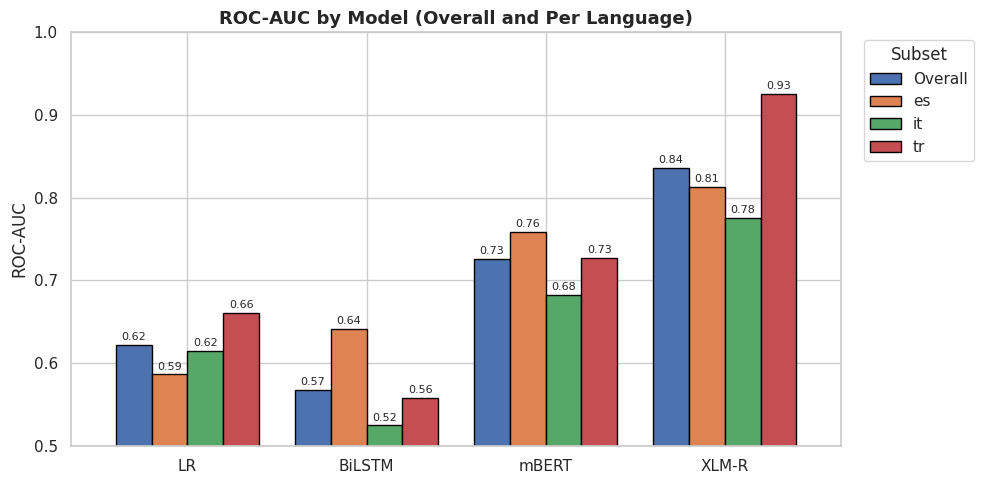

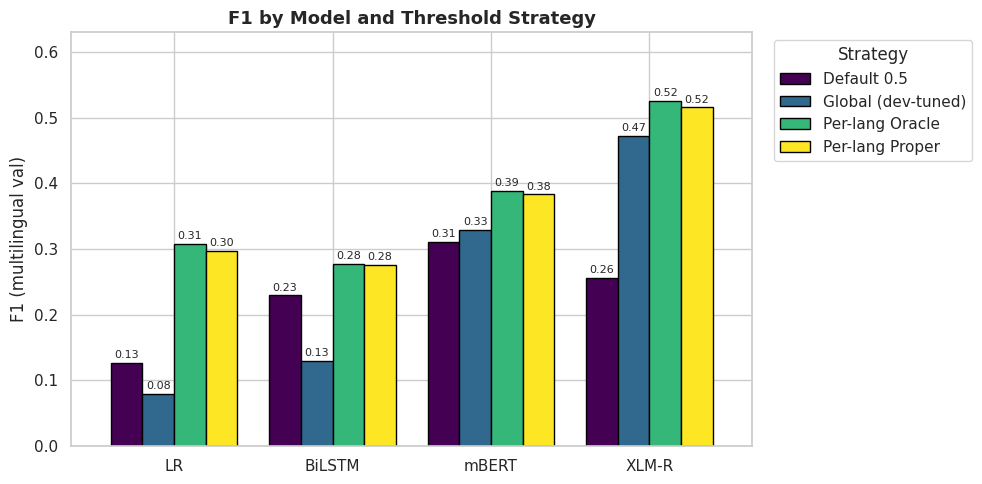

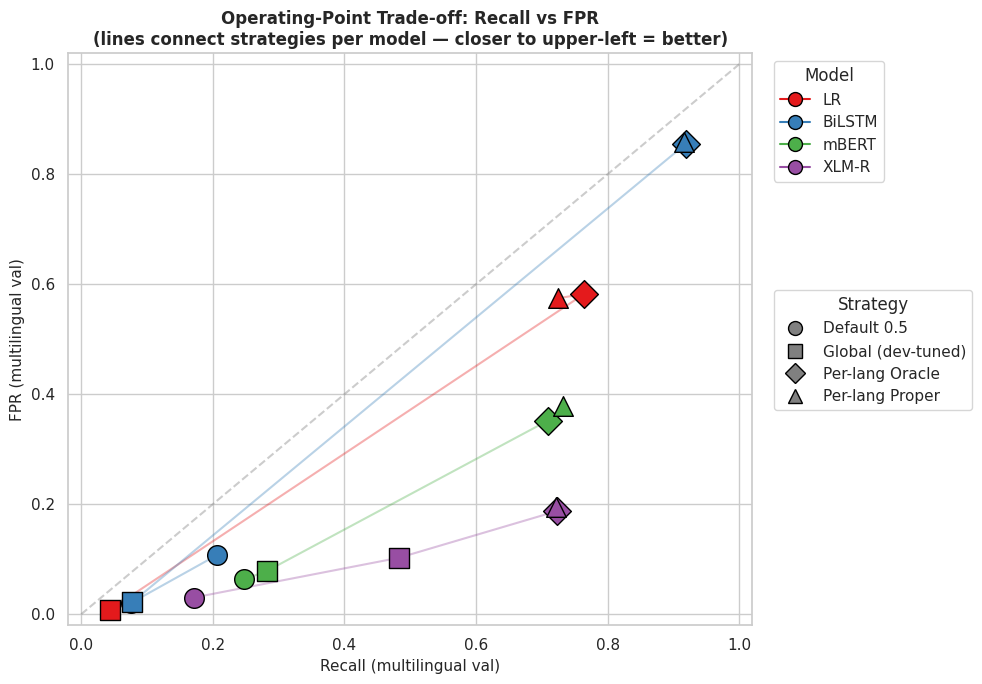

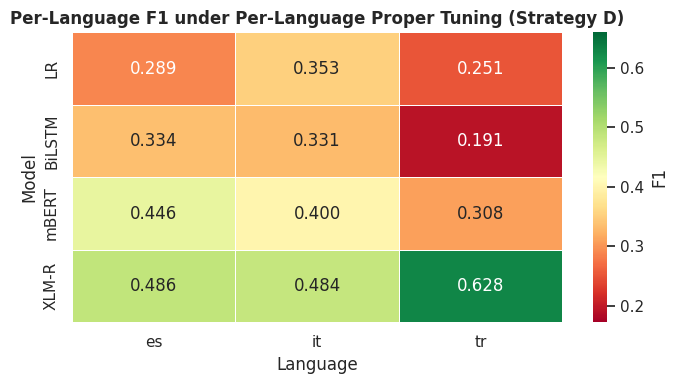


All figures saved to: /content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/module6_outputs/figures
  - fig1_roc_auc_per_language.png
  - fig2_f1_by_strategy.png
  - fig3_recall_vs_fpr.png
  - fig4_per_language_f1_heatmap.png


In [ ]:
# Module 6.6: Generate report figures (saved to module6_outputs/figures/)
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

FIG_DIR = f"{MODULE6_PATH}/figures"
os.makedirs(FIG_DIR, exist_ok=True)

MODEL_ORDER   = ["LR", "BiLSTM", "mBERT", "XLM-R"]
SETTING_ORDER = ["default_0.5", "global_recall@0.7", "per_language_oracle", "per_language_proper"]
SETTING_LABEL = {
    "default_0.5":         "Default 0.5",
    "global_recall@0.7":   "Global (dev-tuned)",
    "per_language_oracle": "Per-lang Oracle",
    "per_language_proper": "Per-lang Proper",
}
sns.set_theme(style="whitegrid", context="notebook")
print_section("Module 6.6: Generating report figures")


# ------------------------------------------------------------------
# Figure 1: ROC-AUC overall + per-language (grouped bars by model)
# ------------------------------------------------------------------
overall_roc = (overall_df[overall_df["setting"] == "default_0.5"]
               .set_index("model")["roc_auc"])
lang_roc = (per_lang_df[per_lang_df["setting"] == "default_0.5"]
            .pivot_table(index="model", columns="lang", values="roc_auc"))
plot_df = lang_roc.copy()
plot_df.insert(0, "Overall", overall_roc)
plot_df = plot_df.reindex(MODEL_ORDER)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df.plot.bar(ax=ax, width=0.8, edgecolor="black")
ax.set_title("ROC-AUC by Model (Overall and Per Language)", fontsize=13, fontweight="bold")
ax.set_ylabel("ROC-AUC")
ax.set_xlabel("")
ax.set_ylim(0.5, 1.0)
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5, linewidth=1)
ax.legend(title="Subset", loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2, fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig1_roc_auc_per_language.png", dpi=150, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------------
# Figure 2: F1 across 4 strategies (grouped bars by model)
# ------------------------------------------------------------------
f1_matrix = (overall_df.pivot_table(index="model", columns="setting", values="f1")
             .reindex(MODEL_ORDER)[SETTING_ORDER])
f1_matrix.columns = [SETTING_LABEL[c] for c in f1_matrix.columns]

fig, ax = plt.subplots(figsize=(10, 5))
f1_matrix.plot.bar(ax=ax, width=0.8, edgecolor="black", colormap="viridis")
ax.set_title("F1 by Model and Threshold Strategy", fontsize=13, fontweight="bold")
ax.set_ylabel("F1 (multilingual val)")
ax.set_xlabel("")
ax.set_ylim(0, max(f1_matrix.values.flatten()) * 1.20)
ax.legend(title="Strategy", loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2, fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig2_f1_by_strategy.png", dpi=150, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------------
# Figure 3: Operating-point trade-off — Recall vs FPR
# Shows that per-language tuning lifts recall, but at very different FPR cost per model
# ------------------------------------------------------------------
markers = {"default_0.5": "o", "global_recall@0.7": "s",
           "per_language_oracle": "D", "per_language_proper": "^"}
colors = {m: c for m, c in zip(MODEL_ORDER, sns.color_palette("Set1", n_colors=4))}

fig, ax = plt.subplots(figsize=(10, 7))
for model in MODEL_ORDER:
    sub = (overall_df[overall_df["model"] == model]
           .set_index("setting").reindex(SETTING_ORDER))
    ax.plot(sub["recall"], sub["fpr"], "-", color=colors[model], alpha=0.35, zorder=1)
    for setting in SETTING_ORDER:
        row = sub.loc[setting]
        ax.scatter(row["recall"], row["fpr"],
                   s=200, marker=markers[setting], color=colors[model],
                   edgecolor="black", linewidth=1, zorder=5)

ax.plot([0, 1], [0, 1], "--", color="grey", alpha=0.4)
ax.set_xlabel("Recall (multilingual val)", fontsize=11)
ax.set_ylabel("FPR (multilingual val)", fontsize=11)
ax.set_title("Operating-Point Trade-off: Recall vs FPR\n"
             "(lines connect strategies per model — closer to upper-left = better)",
             fontsize=12, fontweight="bold")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

model_handles = [mlines.Line2D([], [], color=colors[m], marker="o", linestyle="-",
                                markersize=10, markeredgecolor="black", label=m)
                 for m in MODEL_ORDER]
strat_handles = [mlines.Line2D([], [], color="grey", marker=markers[s], linestyle="",
                                markersize=10, markeredgecolor="black", label=SETTING_LABEL[s])
                 for s in SETTING_ORDER]
leg1 = ax.legend(handles=model_handles, title="Model",
                 loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.add_artist(leg1)
ax.legend(handles=strat_handles, title="Strategy",
          loc="upper left", bbox_to_anchor=(1.02, 0.60))
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig3_recall_vs_fpr.png", dpi=150, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------------
# Figure 4: Per-language F1 heatmap under per_language_proper (D)
# Shows where each model struggles linguistically under the deployable strategy
# ------------------------------------------------------------------
heatmap_data = (per_lang_df[per_lang_df["setting"] == "per_language_proper"]
                .pivot_table(index="model", columns="lang", values="f1")
                .reindex(MODEL_ORDER))

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="RdYlGn",
            cbar_kws={"label": "F1"},
            linewidths=0.5, linecolor="white", ax=ax,
            vmin=heatmap_data.min().min() * 0.9,
            vmax=heatmap_data.max().max() * 1.05)
ax.set_title("Per-Language F1 under Per-Language Proper Tuning (Strategy D)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Language")
ax.set_ylabel("Model")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig4_per_language_f1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


print(f"\nAll figures saved to: {FIG_DIR}")
for f in sorted(os.listdir(FIG_DIR)):
    print(f"  - {f}")

In [ ]:
# Module 6.5: Update project state
STATE_FILE = f"{PROJECT_ROOT}/project_state/run_state.json"

with open(STATE_FILE, "r") as f:
    state = json.load(f)

state["module_6_evaluation"] = {
    "status": "done",
    "settings_evaluated": [
        "default_0.5",
        "global_recall@0.7",
        "per_language_oracle",
        "per_language_proper",
    ],
    "metrics": [
        "roc_auc", "pr_auc",
        "precision", "recall", "f1",
        "fpr", "fnr",
        "positive_prediction_rate",
    ],
    "evaluation_subsets": {
        "default_0.5":         "full multilingual val",
        "global_recall@0.7":   "full multilingual val",
        "per_language_oracle": "full multilingual val",
        "per_language_proper": "val_eval (50% of val, leak-free)",
    },
    "output_dir": MODULE6_PATH,
    "next_step": "report_writeup",
}

with open(STATE_FILE, "w") as f:
    json.dump(state, f, indent=4)

print("Module 6 marked done in run_state.json.")
print("Next step:", state["module_6_evaluation"]["next_step"])

Module 6 marked done in run_state.json.
Next step: report_writeup
